In [1]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes

def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list
# Function to get meal, snack, and mega meal metrics, including mega_meal_frequency and mega_meal_size
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0)

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:  # Make sure we are within the 7-day boundary
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 5:
                meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 6:
                mega_meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        day_index = int(current_event[0] // 24)
        hour = int(current_event[0]) % 24
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)  # Add the number of mega meals

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals)


# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Function to calculate inter-pellet intervals (IPI)
def get_interpellet_intervals(pellettimes):
    IPIs = np.diff(pellettimes)
    return IPIs

# Function to calculate intermeal intervals (IMI)
def get_intermeal_interval(pellettimes, meal_threshold=1/60):
    IPIs = np.diff(pellettimes)
    IMIs = [x for x in IPIs if x > meal_threshold]
    average_IMI = np.mean(IMIs) if IMIs else 0  # Handle case with no IMIs
    return average_IMI

# Load the metafile and process the data
metafile = "..\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

    # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"]  # Store the number of mega meals
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"]  # Store the number of mega meals
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"]  # Store the number of mega meals
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)


# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])

Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [47, 30, 28, 37, 33, 36, 27, 30, 34, 25, 14, 24, 24, 21, 20, 11, 11]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 3, 2, 1, 0, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 0, 0], [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1], [0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 2, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 2, 3, 1, 0, 1, 0, 0, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 2, 2, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 0.7914710335259267
  Mega Meals Size: 7.916666666666667
Mouse FEDXA02:
  Pellets per day: [304, 214, 194, 154, 153, 204, 211, 203, 226, 214, 

In [2]:
# Selectors for grouping mice data
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"}


11 items in output dictionary
12 items in output dictionary


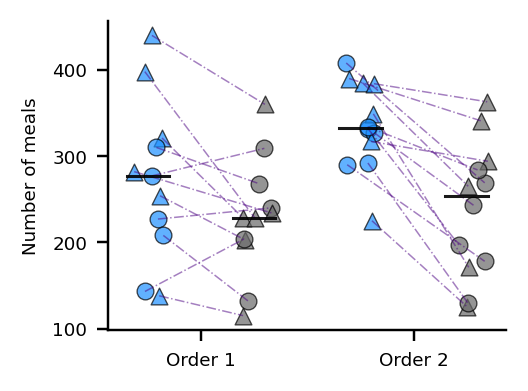

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract combined meal data for PR and NR phases, separated by order
nrpr_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], {"order": 1})
prnr_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], {"order": 2})

# Prepare data for plotting
data = [nrpr_meals[0], nrpr_meals[1], prnr_meals[0], prnr_meals[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Reduced offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Closer positions for minimal gap

# Create a figure and axis
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=220)
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1, alpha=0.9)

# # Customize legend with gender markers and colored text for PR and NR
# custom_lines = [
#     Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
#     Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
# ]
# plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 0.9), frameon=False, fontsize=4)

# # Add combined colored text for PR and NR next to the legend
# plt.text(1.05, 0.65, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
# plt.text(1.05, 0.70, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=6)
plt.yticks(fontsize=6)
plt.xlabel("")
plt.ylabel("Number of meals", fontsize=6)
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
# fig.savefig("connected_meals_scatter_plot.pdf")
#fig.savefig("..//plots/NEW_MEAL_PLOTS/Scatter_meal_number.png")

11 items in output dictionary
12 items in output dictionary


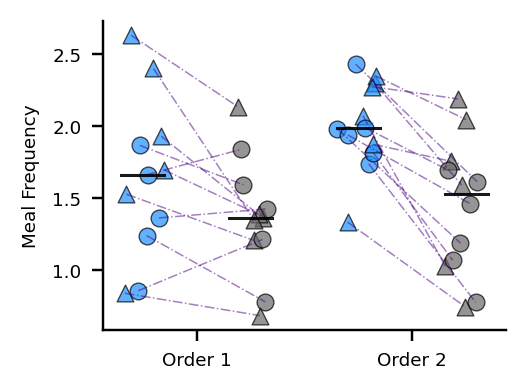

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract combined meal frequency data for PR and NR phases, separated by order
nrpr_frequency = get_data_fields(mice, ["pr_meal_frequency", "nr_meal_frequency"], {"order": 1})
prnr_frequency = get_data_fields(mice, ["pr_meal_frequency", "nr_meal_frequency"], {"order": 2})

# Prepare data for plotting
data = [nrpr_frequency[0], nrpr_frequency[1], prnr_frequency[0], prnr_frequency[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Positions for minimal gap between groups

# Create a figure and axis
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=220)
jitter_strength = 0.02

# Plot data points and lines between PR and NR data
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Plot line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1, alpha=0.9)

# # Customize legend with no frame and no title
# custom_lines = [
#     Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
#     Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
# ]
# plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 0.9), frameon=False, fontsize=4)

# # Add combined colored text for PR and NR next to the legend
# plt.text(1.05, 0.65, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
# plt.text(1.05, 0.70, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=6)
plt.yticks(fontsize=6)
plt.xlabel("")
plt.ylabel("Meal Frequency", fontsize=6)
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
#fig.savefig("..//plots/NEW_MEAL_PLOTS/Scatter_meal_frequency.png")


11 items in output dictionary
12 items in output dictionary


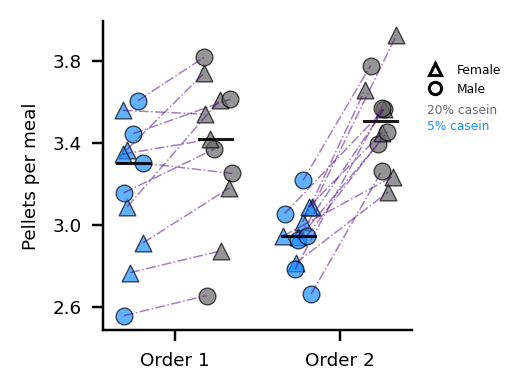

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract combined meal size data for PR and NR phases, separated by order
nrpr_size = get_data_fields(mice, ["pr_meal_size", "nr_meal_size"], {"order": 1})
prnr_size = get_data_fields(mice, ["pr_meal_size", "nr_meal_size"], {"order": 2})

# Prepare data for plotting
data = [nrpr_size[0], nrpr_size[1], prnr_size[0], prnr_size[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Closer positions for minimal gap

# Create a figure and axis
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=220)
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1, alpha=0.9)

# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 0.9), frameon=False, fontsize=4)

# Add combined colored text for PR and NR next to the legend
plt.text(1.05, 0.65, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
plt.text(1.05, 0.70, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]], ["Order 1", "Order 2"], fontsize=6)
plt.yticks(np.arange(2.6, 4, 0.4), fontsize=6)
plt.xlabel("")
plt.ylabel("Pellets per meal", fontsize=6)
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
fig.savefig("..//plots/NEW_MEAL_PLOTS/Scatter_meal_size.png")


11 items in output dictionary
12 items in output dictionary


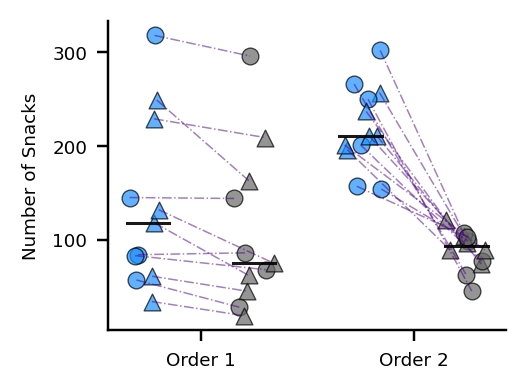

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract combined snack count data for PR and NR phases, separated by order
nrpr_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], {"order": 1})
prnr_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], {"order": 2})

# Prepare data for plotting
data = [nrpr_snacks[0], nrpr_snacks[1], prnr_snacks[0], prnr_snacks[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Closer positions for minimal gap

# Create a figure and axis
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=220)
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1, alpha=0.9)

# # Customize legend with no frame and no title
# custom_lines = [
#     Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
#     Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
# ]
# plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 0.9), frameon=False, fontsize=4)

# # Add combined colored text for PR and NR next to the legend
# plt.text(1.05, 0.65, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
# plt.text(1.05, 0.70, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]], ["Order 1", "Order 2"], fontsize=6)
plt.yticks(fontsize=6)
plt.xlabel("")
plt.ylabel("Number of Snacks", fontsize=6)
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
#fig.savefig("..//plots/NEW_MEAL_PLOTS/Scatter_snack_number.png")


11 items in output dictionary
12 items in output dictionary


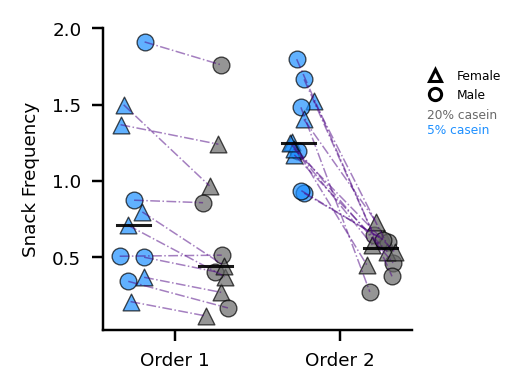

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract combined snack frequency data for PR and NR phases, separated by order
nrpr_snack_freq = get_data_fields(mice, ["pr_snack_frequency", "nr_snack_frequency"], {"order": 1})
prnr_snack_freq = get_data_fields(mice, ["pr_snack_frequency", "nr_snack_frequency"], {"order": 2})

# Prepare data for plotting
data = [nrpr_snack_freq[0], nrpr_snack_freq[1], prnr_snack_freq[0], prnr_snack_freq[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Closer positions for minimal gap

# Create a figure and axis
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=220)
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1, alpha=0.9)

# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 0.9), frameon=False, fontsize=4)

# Add combined colored text for PR and NR next to the legend
plt.text(1.05, 0.65, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
plt.text(1.05, 0.70, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]], ["Order 1", "Order 2"], fontsize=6)
plt.yticks(fontsize=6)
plt.xlabel("")
plt.ylabel("Snack Frequency", fontsize=6)
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
fig.savefig("..//plots/NEW_MEAL_PLOTS/Scatter_snack_frequency.png")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


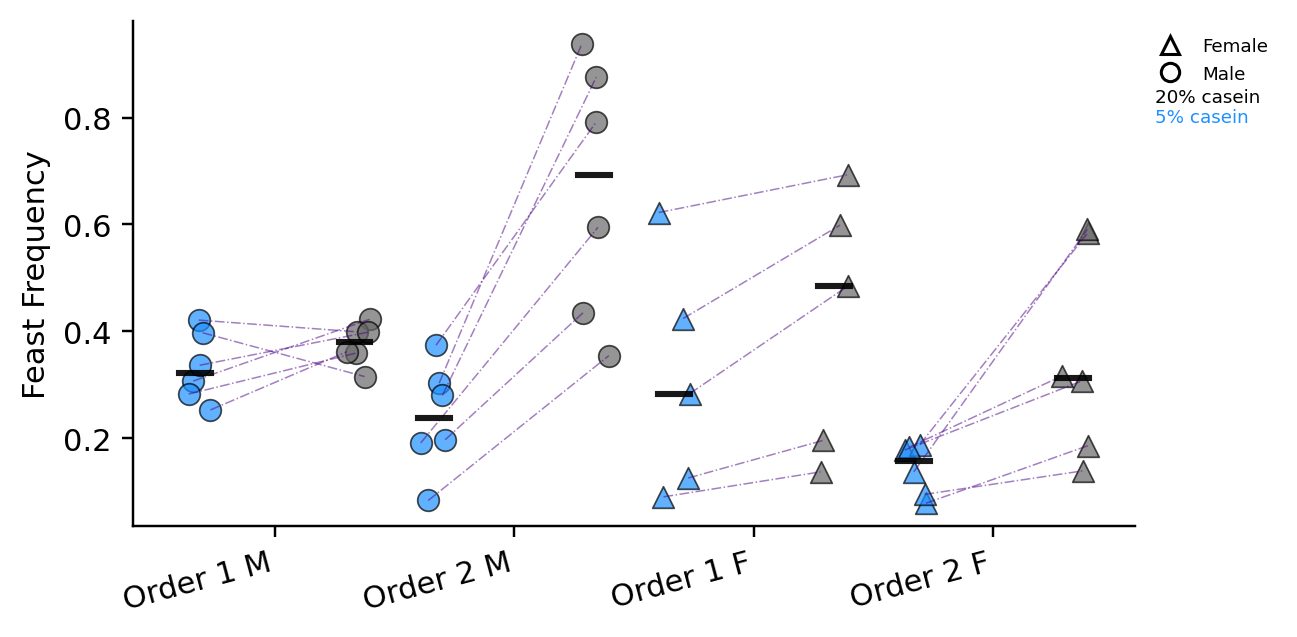

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract Feast frequency data for PR and NR phases, separated by order and sex
nrpr_male_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 1, "sex": "M"})
prnr_male_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 2, "sex": "M"})
nrpr_female_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 1, "sex": "F"})
prnr_female_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 2, "sex": "F"})

# Prepare data for plotting
data = [
    nrpr_male_feast_freq[0], nrpr_male_feast_freq[1], prnr_male_feast_freq[0], prnr_male_feast_freq[1],
    nrpr_female_feast_freq[0], nrpr_female_feast_freq[1], prnr_female_feast_freq[0], prnr_female_feast_freq[1]
]
group_labels = [
    "Order 1 Male (PR)", "Order 1 Male (NR)", "Order 2 Male (PR)", "Order 2 Male (NR)",
    "Order 1 Female (PR)", "Order 1 Female (NR)", "Order 2 Female (PR)", "Order 2 Female (NR)"
]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}
offset = {"PR": -0.5, "NR": 0.5}  # Increased spacing between PR and NR
group_positions = {
    "Order 1 Male": 0, "Order 2 Male": 1.5,  # Increased gap between orders
    "Order 1 Female": 3, "Order 2 Female": 4.5  # Increased gap between orders
}

# Create figure
fig, ax = plt.subplots(figsize=(6, 3), dpi=220)
jitter_strength = 0.1  # Keep jitter to prevent overlapping points

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1 Male", "Order 2 Male", "Order 1 Female", "Order 2 Female"]):
    pr_data = data[i * 2]   # PR data for each group
    nr_data = data[i * 2 + 1]  # NR data for each group

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw dashed-dot indigo line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with gender-specific markers
        sex = "F" if "Female" in label else "M"
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=markers[sex], s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=markers[sex], s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet in ["PR", "NR"]:
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.1, x_val + 0.1], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=6, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=6, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(1, 1), frameon=False, fontsize=6)

# Add combined colored text for PR and NR next to the legend
plt.text(1.02, 0.80, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=6)
plt.text(1.02, 0.84, '20% casein', color='black', transform=ax.transAxes, fontsize=6)

# Adjust x-axis labels to match new group spacing
plt.xticks([group_positions["Order 1 Male"], group_positions["Order 2 Male"],
            group_positions["Order 1 Female"], group_positions["Order 2 Female"]],
           ["Order 1 M", "Order 2 M", "Order 1 F", "Order 2 F"], fontsize=10, rotation=15, ha="right")

plt.xlabel("")
plt.ylabel("Feast Frequency", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure
fig.savefig("..//plots/NEW_MEAL_PLOTS/Scatter_FEAST_frequency.png")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


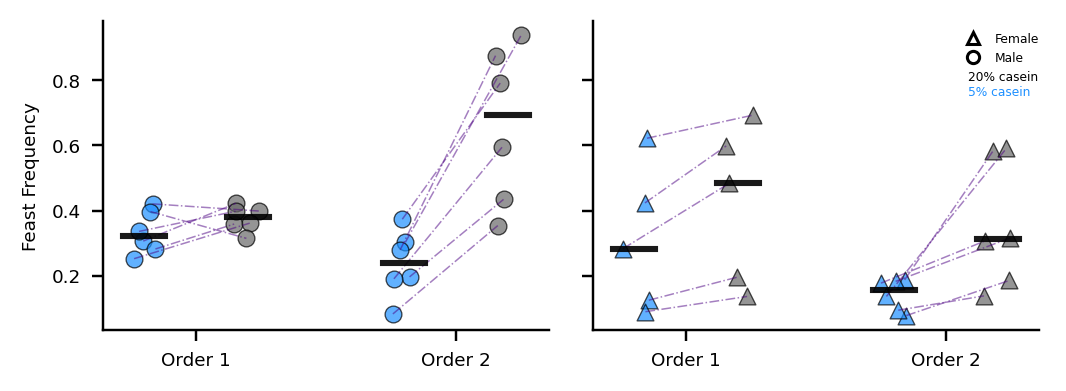

In [142]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract Feast Frequency data for PR and NR phases, separated by order and sex
nrpr_male_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 1, "sex": "M"})
prnr_male_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 2, "sex": "M"})
nrpr_female_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 1, "sex": "F"})
prnr_female_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 2, "sex": "F"})

# Prepare data for plotting
male_data = [
    nrpr_male_feast_freq[0], nrpr_male_feast_freq[1], prnr_male_feast_freq[0], prnr_male_feast_freq[1]
]
female_data = [
    nrpr_female_feast_freq[0], nrpr_female_feast_freq[1], prnr_female_feast_freq[0], prnr_female_feast_freq[1]
]
group_labels = ["Order 1", "Order 2"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}

# Adjusted x-positions to reduce the gap
group_positions = {"Order 1": 0, "Order 2": 0.25}
offset = {"PR": -0.05, "NR": 0.05}  # Spacing between PR and NR
jitter_strength = 0.015  # Smaller jitter to avoid excessive spread

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(5, 1.88), dpi=220, sharey=True)
axes[0].set_title("", fontsize=6)
axes[1].set_title("", fontsize=6)

# Plot Male Data (Left subplot)
for order_idx, order in enumerate(group_labels):
    pr_x = [group_positions[order] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in male_data[order_idx * 2]]
    nr_x = [group_positions[order] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in male_data[order_idx * 2 + 1]]

    # Draw connection lines
    for i in range(len(male_data[order_idx * 2])):
        axes[0].plot([pr_x[i], nr_x[i]], [male_data[order_idx * 2][i], male_data[order_idx * 2 + 1][i]], 
                     color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

    # Scatterplot for PR and NR values
    sns.scatterplot(x=pr_x, y=male_data[order_idx * 2], color=colors["PR"], 
                    marker=markers["M"], s=30, alpha=0.7, edgecolor="black", ax=axes[0])
    sns.scatterplot(x=nr_x, y=male_data[order_idx * 2 + 1], color=colors["NR"], 
                    marker=markers["M"], s=30, alpha=0.7, edgecolor="black", ax=axes[0])

# Plot Female Data (Right subplot)
for order_idx, order in enumerate(group_labels):
    pr_x = [group_positions[order] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in female_data[order_idx * 2]]
    nr_x = [group_positions[order] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in female_data[order_idx * 2 + 1]]

    # Draw connection lines
    for i in range(len(female_data[order_idx * 2])):
        axes[1].plot([pr_x[i], nr_x[i]], [female_data[order_idx * 2][i], female_data[order_idx * 2 + 1][i]], 
                     color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

    # Scatterplot for PR and NR values
    sns.scatterplot(x=pr_x, y=female_data[order_idx * 2], color=colors["PR"], 
                    marker=markers["F"], s=30, alpha=0.7, edgecolor="black", ax=axes[1])
    sns.scatterplot(x=nr_x, y=female_data[order_idx * 2 + 1], color=colors["NR"], 
                    marker=markers["F"], s=30, alpha=0.7, edgecolor="black", ax=axes[1])

# Add median lines for PR and NR
for ax, data in zip(axes, [male_data, female_data]):
    for order_idx, order in enumerate(group_labels):
        for phase in ["PR", "NR"]:
            median_value = np.median(data[order_idx * 2] if phase == "PR" else data[order_idx * 2 + 1])
            x_val = group_positions[order] + offset[phase]
            ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customise plot appearance
for ax in axes:
    ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]])
    ax.set_xticklabels(group_labels, fontsize=6)
    ax.set_xlabel("")
    ax.tick_params(axis='y', labelsize=6)
    ax.set_ylabel("Feast Frequency", fontsize=6)
    sns.despine(ax=ax)

# Add legend for sex markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
]
axes[1].legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(0.8, 1), frameon=False, fontsize=4)

# Add text labels for PR and NR phases
axes[1].text(0.84, 0.76, '5% casein', color='dodgerblue', transform=axes[1].transAxes, fontsize=4)
axes[1].text(0.84, 0.81, '20% casein', color='black', transform=axes[1].transAxes, fontsize=4)

plt.tight_layout()
plt.show()


fig.savefig("../plots/NEW_MEAL_PLOTS/connected_FEAST_FREQUENCY_scatter_plot.png", bbox_inches='tight', dpi=220)


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


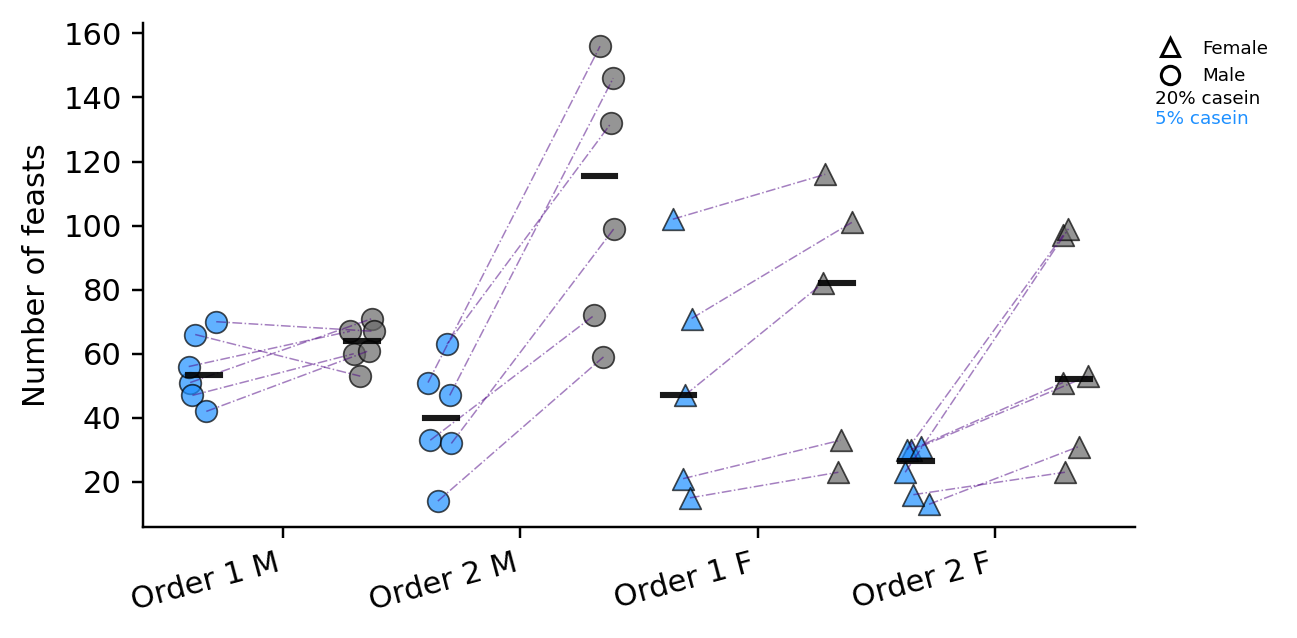

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract Feast frequency data for PR and NR phases, separated by order and sex
nrpr_male_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 1, "sex": "M"})
prnr_male_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 2, "sex": "M"})
nrpr_female_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 1, "sex": "F"})
prnr_female_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 2, "sex": "F"})

# Prepare data for plotting
data = [
    nrpr_male_feast_freq[0], nrpr_male_feast_freq[1], prnr_male_feast_freq[0], prnr_male_feast_freq[1],
    nrpr_female_feast_freq[0], nrpr_female_feast_freq[1], prnr_female_feast_freq[0], prnr_female_feast_freq[1]
]
group_labels = [
    "Order 1 Male (PR)", "Order 1 Male (NR)", "Order 2 Male (PR)", "Order 2 Male (NR)",
    "Order 1 Female (PR)", "Order 1 Female (NR)", "Order 2 Female (PR)", "Order 2 Female (NR)"
]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}
offset = {"PR": -0.5, "NR": 0.5}  # Spacing between PR and NR
group_positions = {
    "Order 1 Male": 0, "Order 2 Male": 1.5,  # Increased gap
    "Order 1 Female": 3, "Order 2 Female": 4.5  # Increased gap
}

# Create figure
fig, ax = plt.subplots(figsize=(6, 3), dpi=220)
jitter_strength = 0.1

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1 Male", "Order 2 Male", "Order 1 Female", "Order 2 Female"]):
    pr_data = data[i * 2]   # PR data for each group
    nr_data = data[i * 2 + 1]  # NR data for each group

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw dashed-dot indigo line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with gender-specific markers
        sex = "F" if "Female" in label else "M"
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=markers[sex], s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=markers[sex], s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet in ["PR", "NR"]:
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.1, x_val + 0.1], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=6, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=6, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(1, 1), frameon=False, fontsize=6)

# Add combined colored text for PR and NR next to the legend
plt.text(1.02, 0.80, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=6)
plt.text(1.02, 0.84, '20% casein', color='black', transform=ax.transAxes, fontsize=6)

# Adjust x-axis labels to match new group spacing
plt.xticks([group_positions["Order 1 Male"], group_positions["Order 2 Male"],
            group_positions["Order 1 Female"], group_positions["Order 2 Female"]],
           ["Order 1 M", "Order 2 M", "Order 1 F", "Order 2 F"], fontsize=10, rotation=15, ha="right")

plt.xlabel("")
plt.ylabel("Number of feasts", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


# Save the figure
#fig.savefig("..//plots/NEW_MEAL_PLOTS/Scatter_FEAST_NUMBER.png")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


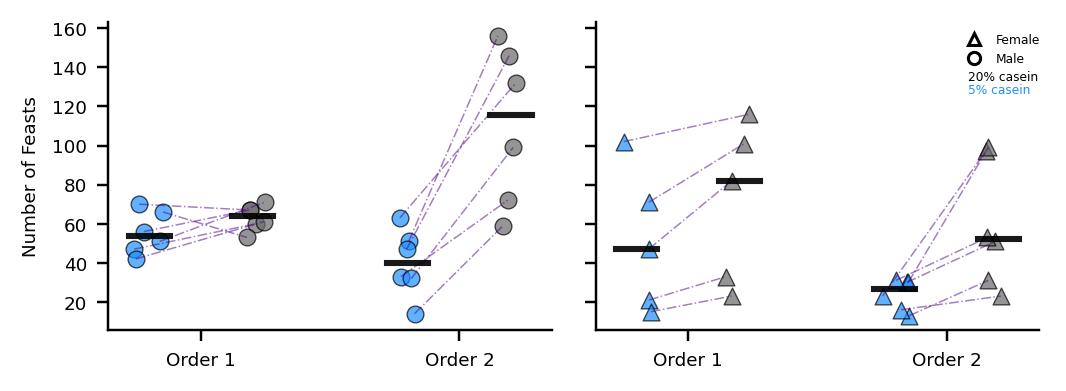

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract Feast Frequency data for PR and NR phases, separated by order and sex
nrpr_male_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 1, "sex": "M"})
prnr_male_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 2, "sex": "M"})
nrpr_female_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 1, "sex": "F"})
prnr_female_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 2, "sex": "F"})

# Prepare data for plotting
male_data = [
    nrpr_male_feast_freq[0], nrpr_male_feast_freq[1], prnr_male_feast_freq[0], prnr_male_feast_freq[1]
]
female_data = [
    nrpr_female_feast_freq[0], nrpr_female_feast_freq[1], prnr_female_feast_freq[0], prnr_female_feast_freq[1]
]
group_labels = ["Order 1", "Order 2"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}

# Adjusted x-positions to reduce the gap
group_positions = {"Order 1": 0, "Order 2": 0.25}
offset = {"PR": -0.05, "NR": 0.05}  # Spacing between PR and NR
jitter_strength = 0.015  # Smaller jitter to avoid excessive spread

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(5, 1.88), dpi=220, sharey=True)
axes[0].set_title("", fontsize=6)
axes[1].set_title("", fontsize=6)

# Plot Male Data (Left subplot)
for order_idx, order in enumerate(group_labels):
    pr_x = [group_positions[order] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in male_data[order_idx * 2]]
    nr_x = [group_positions[order] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in male_data[order_idx * 2 + 1]]

    # Draw connection lines
    for i in range(len(male_data[order_idx * 2])):
        axes[0].plot([pr_x[i], nr_x[i]], [male_data[order_idx * 2][i], male_data[order_idx * 2 + 1][i]], 
                     color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

    # Scatterplot for PR and NR values
    sns.scatterplot(x=pr_x, y=male_data[order_idx * 2], color=colors["PR"], 
                    marker=markers["M"], s=30, alpha=0.7, edgecolor="black", ax=axes[0])
    sns.scatterplot(x=nr_x, y=male_data[order_idx * 2 + 1], color=colors["NR"], 
                    marker=markers["M"], s=30, alpha=0.7, edgecolor="black", ax=axes[0])

# Plot Female Data (Right subplot)
for order_idx, order in enumerate(group_labels):
    pr_x = [group_positions[order] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in female_data[order_idx * 2]]
    nr_x = [group_positions[order] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in female_data[order_idx * 2 + 1]]

    # Draw connection lines
    for i in range(len(female_data[order_idx * 2])):
        axes[1].plot([pr_x[i], nr_x[i]], [female_data[order_idx * 2][i], female_data[order_idx * 2 + 1][i]], 
                     color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

    # Scatterplot for PR and NR values
    sns.scatterplot(x=pr_x, y=female_data[order_idx * 2], color=colors["PR"], 
                    marker=markers["F"], s=30, alpha=0.7, edgecolor="black", ax=axes[1])
    sns.scatterplot(x=nr_x, y=female_data[order_idx * 2 + 1], color=colors["NR"], 
                    marker=markers["F"], s=30, alpha=0.7, edgecolor="black", ax=axes[1])

# Add median lines for PR and NR
for ax, data in zip(axes, [male_data, female_data]):
    for order_idx, order in enumerate(group_labels):
        for phase in ["PR", "NR"]:
            median_value = np.median(data[order_idx * 2] if phase == "PR" else data[order_idx * 2 + 1])
            x_val = group_positions[order] + offset[phase]
            ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customise plot appearance
for ax in axes:
    ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]])
    ax.set_xticklabels(group_labels, fontsize=6)
    ax.set_xlabel("")
    ax.tick_params(axis='y', labelsize=6)
    ax.set_ylabel("Number of Feasts", fontsize=6)
    sns.despine(ax=ax)

# Add legend for sex markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
]
axes[1].legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(0.8, 1), frameon=False, fontsize=4)

# Add text labels for PR and NR phases
axes[1].text(0.84, 0.77, '5% casein', color='dodgerblue', transform=axes[1].transAxes, fontsize=4)
axes[1].text(0.84, 0.81, '20% casein', color='black', transform=axes[1].transAxes, fontsize=4)

plt.tight_layout()
plt.show()

# Save the figure

#fig.savefig("../plots/NEW_MEAL_PLOTS/connected_FEAST_NUMBER_scatter_plot.png", bbox_inches='tight', dpi=220)


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


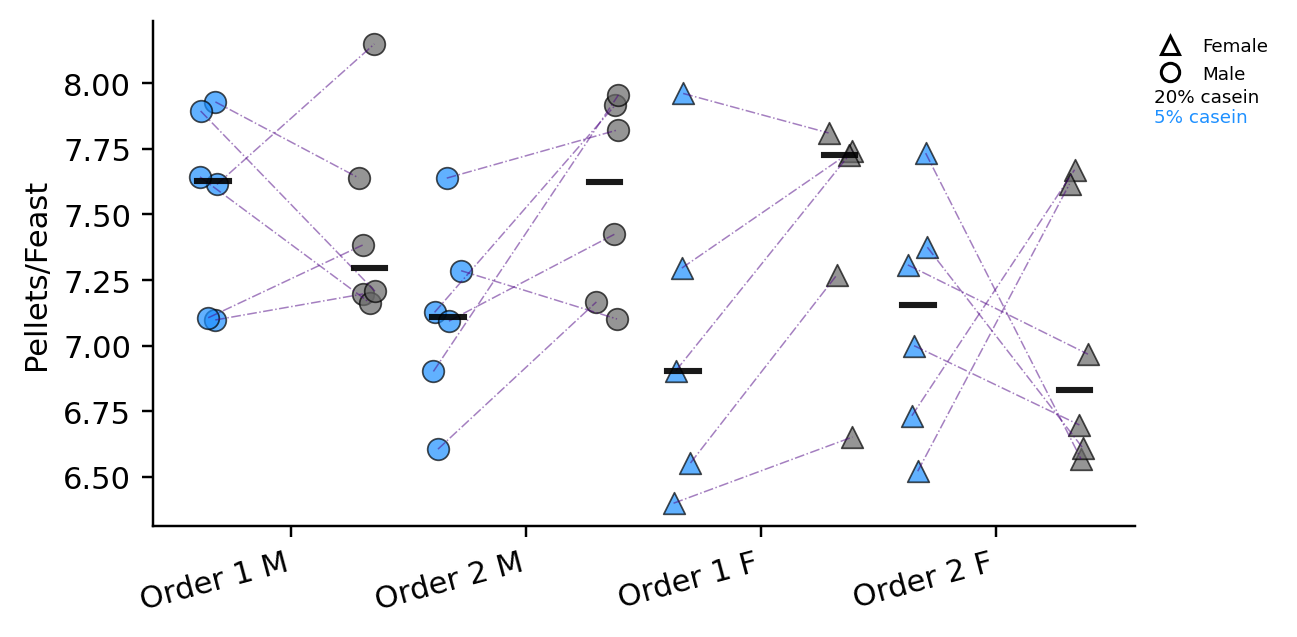

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract Feast size data for PR and NR phases, separated by order and sex
nrpr_male_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 1, "sex": "M"})
prnr_male_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 2, "sex": "M"})
nrpr_female_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 1, "sex": "F"})
prnr_female_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 2, "sex": "F"})

# Prepare data for plotting
data = [
    nrpr_male_feast_size[0], nrpr_male_feast_size[1], prnr_male_feast_size[0], prnr_male_feast_size[1],
    nrpr_female_feast_size[0], nrpr_female_feast_size[1], prnr_female_feast_size[0], prnr_female_feast_size[1]
]
group_labels = [
    "Order 1 Male (PR)", "Order 1 Male (NR)", "Order 2 Male (PR)", "Order 2 Male (NR)",
    "Order 1 Female (PR)", "Order 1 Female (NR)", "Order 2 Female (PR)", "Order 2 Female (NR)"
]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}
offset = {"PR": -0.5, "NR": 0.5}  # Spacing between PR and NR
group_positions = {
    "Order 1 Male": 0, "Order 2 Male": 1.5,  # Increased gap
    "Order 1 Female": 3, "Order 2 Female": 4.5  # Increased gap
}

# Create figure
fig, ax = plt.subplots(figsize=(6, 3), dpi=220)
jitter_strength = 0.1  # Adjusted jitter for better separation

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1 Male", "Order 2 Male", "Order 1 Female", "Order 2 Female"]):
    pr_data = data[i * 2]   # PR data for each group
    nr_data = data[i * 2 + 1]  # NR data for each group

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw dashed-dot indigo line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with gender-specific markers
        sex = "F" if "Female" in label else "M"
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=markers[sex], s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=markers[sex], s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet in ["PR", "NR"]:
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.1, x_val + 0.1], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=6, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=6, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(1, 1), frameon=False, fontsize=6)

# Add combined colored text for PR and NR next to the legend
plt.text(1.02, 0.80, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=6)
plt.text(1.02, 0.84, '20% casein', color='black', transform=ax.transAxes, fontsize=6)

# Adjust x-axis labels to match new group spacing
plt.xticks([group_positions["Order 1 Male"], group_positions["Order 2 Male"],
            group_positions["Order 1 Female"], group_positions["Order 2 Female"]],
           ["Order 1 M", "Order 2 M", "Order 1 F", "Order 2 F"], fontsize=10, rotation=15, ha="right")

plt.xlabel("")
plt.ylabel("Pellets/Feast", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


# Save the figure
fig.savefig("..//plots/NEW_MEAL_PLOTS/Scatter_FEAST_Size.png")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


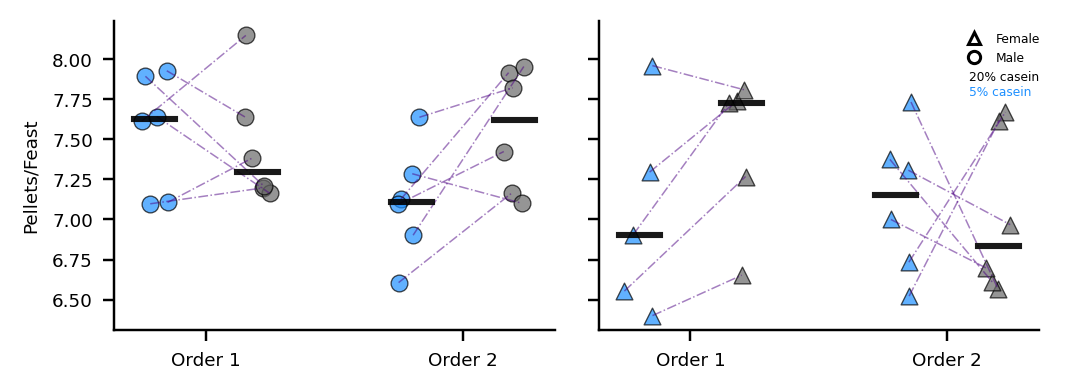

In [145]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract Feast size data for PR and NR phases, separated by order and sex
nrpr_male_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 1, "sex": "M"})
prnr_male_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 2, "sex": "M"})
nrpr_female_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 1, "sex": "F"})
prnr_female_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 2, "sex": "F"})

# Prepare data for plotting
male_data = [
    nrpr_male_feast_size[0], nrpr_male_feast_size[1], prnr_male_feast_size[0], prnr_male_feast_size[1]
]
female_data = [
    nrpr_female_feast_size[0], nrpr_female_feast_size[1], prnr_female_feast_size[0], prnr_female_feast_size[1]
]
group_labels = ["Order 1", "Order 2"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}

# Adjusted x-positions to reduce the gap
group_positions = {"Order 1": 0, "Order 2": 0.25}
offset = {"PR": -0.05, "NR": 0.05}  # Spacing between PR and NR
jitter_strength = 0.015  # Smaller jitter to avoid excessive spread

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(5, 1.88), dpi=220, sharey=True)
axes[0].set_title("", fontsize=6)
axes[1].set_title("", fontsize=6)

# Plot Male Data (Left subplot)
for order_idx, order in enumerate(group_labels):
    pr_x = [group_positions[order] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in male_data[order_idx * 2]]
    nr_x = [group_positions[order] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in male_data[order_idx * 2 + 1]]

    # Draw connection lines
    for i in range(len(male_data[order_idx * 2])):
        axes[0].plot([pr_x[i], nr_x[i]], [male_data[order_idx * 2][i], male_data[order_idx * 2 + 1][i]], 
                     color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

    # Scatterplot for PR and NR values
    sns.scatterplot(x=pr_x, y=male_data[order_idx * 2], color=colors["PR"], 
                    marker=markers["M"], s=30, alpha=0.7, edgecolor="black", ax=axes[0])
    sns.scatterplot(x=nr_x, y=male_data[order_idx * 2 + 1], color=colors["NR"], 
                    marker=markers["M"], s=30, alpha=0.7, edgecolor="black", ax=axes[0])

# Plot Female Data (Right subplot)
for order_idx, order in enumerate(group_labels):
    pr_x = [group_positions[order] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in female_data[order_idx * 2]]
    nr_x = [group_positions[order] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in female_data[order_idx * 2 + 1]]

    # Draw connection lines
    for i in range(len(female_data[order_idx * 2])):
        axes[1].plot([pr_x[i], nr_x[i]], [female_data[order_idx * 2][i], female_data[order_idx * 2 + 1][i]], 
                     color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

    # Scatterplot for PR and NR values
    sns.scatterplot(x=pr_x, y=female_data[order_idx * 2], color=colors["PR"], 
                    marker=markers["F"], s=30, alpha=0.7, edgecolor="black", ax=axes[1])
    sns.scatterplot(x=nr_x, y=female_data[order_idx * 2 + 1], color=colors["NR"], 
                    marker=markers["F"], s=30, alpha=0.7, edgecolor="black", ax=axes[1])

# Add median lines for PR and NR
for ax, data in zip(axes, [male_data, female_data]):
    for order_idx, order in enumerate(group_labels):
        for phase in ["PR", "NR"]:
            median_value = np.median(data[order_idx * 2] if phase == "PR" else data[order_idx * 2 + 1])
            x_val = group_positions[order] + offset[phase]
            ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customise plot appearance
for ax in axes:
    ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]])
    ax.set_xticklabels(group_labels, fontsize=6)
    ax.set_xlabel("")
    ax.tick_params(axis='y', labelsize=6)
    ax.set_ylabel("Pellets/Feast", fontsize=6)
    sns.despine(ax=ax)

# Add legend for sex markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
]
axes[1].legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(0.8, 1), frameon=False, fontsize=4)

# Add text labels for PR and NR phases
axes[1].text(0.84, 0.76, '5% casein', color='dodgerblue', transform=axes[1].transAxes, fontsize=4)
axes[1].text(0.84, 0.81, '20% casein', color='black', transform=axes[1].transAxes, fontsize=4)

plt.tight_layout()
plt.show()

fig.savefig("../plots/NEW_MEAL_PLOTS/connected_FEAST_SIZE_scatter_plot.png", bbox_inches='tight', dpi=220)


11 items in output dictionary
12 items in output dictionary


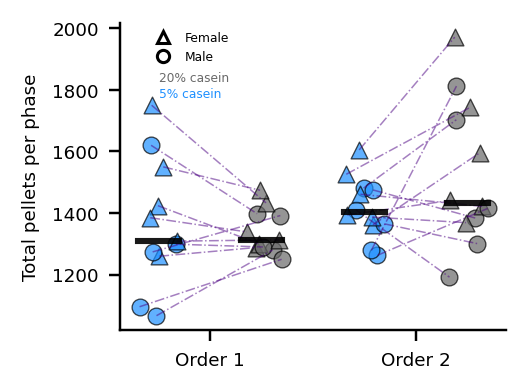

In [186]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Combine male and female data for PR and NR phases within each order
nrpr_order1_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 1})
prnr_order2_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 2})

# Sum pellets per day for each order and phase
nrpr_order1_pr_pellets = [sum(pellets) for pellets in nrpr_order1_data[0]]
nrpr_order1_nr_pellets = [sum(pellets) for pellets in nrpr_order1_data[1]]
prnr_order2_pr_pellets = [sum(pellets) for pellets in prnr_order2_data[0]]
prnr_order2_nr_pellets = [sum(pellets) for pellets in prnr_order2_data[1]]

# Prepare data for plotting
data = [nrpr_order1_pr_pellets, nrpr_order1_nr_pellets, prnr_order2_pr_pellets, prnr_order2_nr_pellets]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]

colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Position for minimal gap between groups

# Create a figure and axis
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=220)
jitter_strength = 0.02

# Plot combined data points with gender-specific markers
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for each order
    nr_data = data[i * 2 + 1]  # NR data for each order

    # Apply jitter to x-positions and assign markers based on sex
    pr_x = [group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in pr_data]
    nr_x = [group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in nr_data]
    
    # Draw line connecting PR and NR for each combined data point
    for j in range(len(pr_data)):
        ax.plot([pr_x[j], nr_x[j]], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with markers for gender (combined data)
        marker = '^' if j % 2 == 0 else 'o'  # Alternating marker for visibility in combined data
        sns.scatterplot(x=[pr_x[j]], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x[j]], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customize legend with combined markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black',  linestyle='', markersize=4, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(0.05, 1.01), frameon=False, fontsize=4)





# Add text labels for PR and NR
plt.text(0.1,0.76, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
plt.text(0.1, 0.81, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=6)
plt.yticks(fontsize=6)
plt.xlabel("")
plt.ylabel("Total pellets per phase",fontsize=6)
sns.despine()
plt.tight_layout()

plt.show()

# Save the figure
fig.savefig("..//plots/NEW_MEAL_PLOTS/connected_total_pellets_scatter_plot.png")


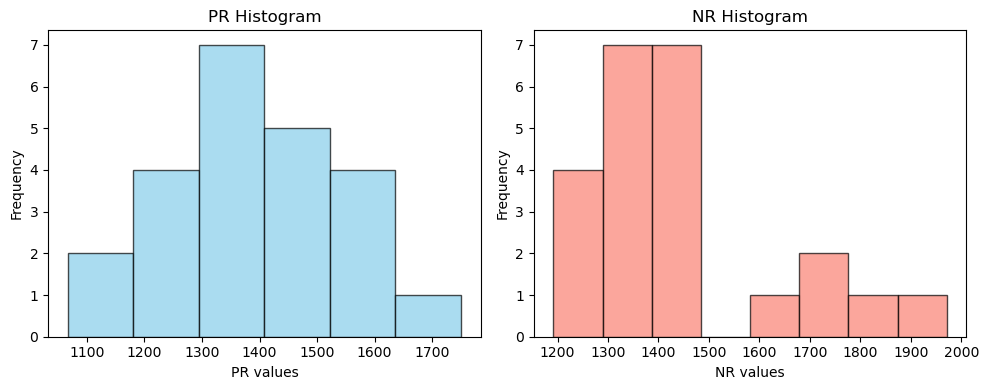

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot

# PR data for all 23 mice (males + females combined)
pr = np.array([
    1362, 1365, 1605, 1481, 1526, 1475, 1260, 1067, 1424, 1274, 1385, 1620,
    1387, 1411, 1461, 1263, 1394, 1279, 1750, 1299, 1550, 1096, 1309
])

# NR data for all 23 mice (males + females combined)
nr = np.array([
    1596, 1301, 1971, 1703, 1743, 1384, 1288, 1280, 1301, 1392, 1339, 1398,
    1369, 1192, 1422, 1415, 1441, 1812, 1433, 1290, 1474, 1250, 1313
])


# Create side-by-side histograms for PR and NR
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Histogram for PR
axs[0].hist(pr, bins='auto', color='skyblue', edgecolor='black', alpha=0.7)
axs[0].set_title('PR Histogram')
axs[0].set_xlabel('PR values')
axs[0].set_ylabel('Frequency')

# Histogram for NR
axs[1].hist(nr, bins='auto', color='salmon', edgecolor='black', alpha=0.7)
axs[1].set_title('NR Histogram')
axs[1].set_xlabel('NR values')
axs[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


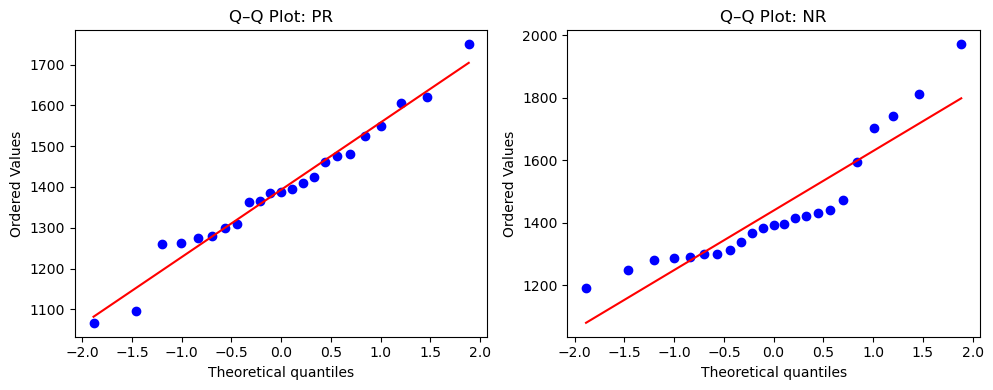

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Q–Q plot for PR
probplot(pr, dist='norm', plot=axs[0])
axs[0].set_title('Q–Q Plot: PR')

# Q–Q plot for NR
probplot(nr, dist='norm', plot=axs[1])
axs[1].set_title('Q–Q Plot: NR')

plt.tight_layout()
plt.show()


PR (Order=1)  -> W=0.960, p=0.7659
NR (Order=1)  -> W=0.920, p=0.3182
PR (Order=2)  -> W=0.974, p=0.9442
NR (Order=2)  -> W=0.942, p=0.5264


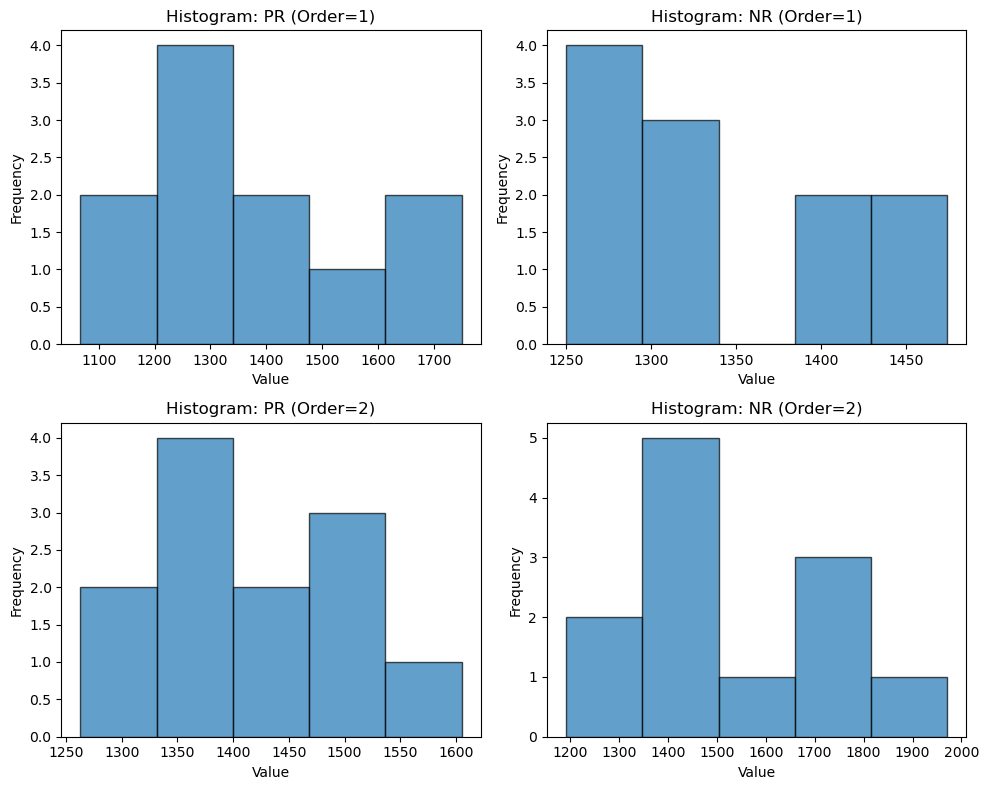

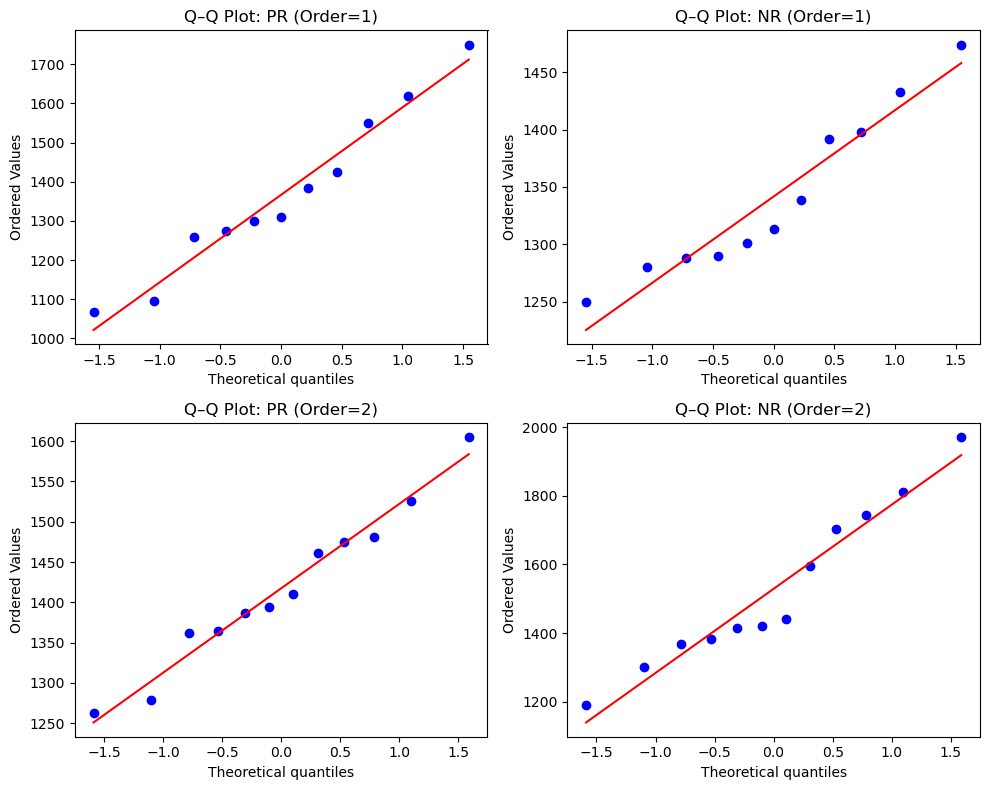

In [8]:
import numpy as np
from scipy.stats import shapiro

pr_order1 = np.array([1260,1067,1424,1274,1385,1620,1750,1299,1550,1096,1309])
nr_order1 = np.array([1288,1280,1301,1392,1339,1398,1433,1290,1474,1250,1313])

pr_order2 = np.array([1362,1365,1605,1481,1526,1475,1387,1411,1461,1263,1394,1279])
nr_order2 = np.array([1596,1301,1971,1703,1743,1384,1369,1192,1422,1415,1441,1812])

data_sets = {
    "PR (Order=1)": pr_order1,
    "NR (Order=1)": nr_order1,
    "PR (Order=2)": pr_order2,
    "NR (Order=2)": nr_order2
}

for name, arr in data_sets.items():
    stat, p = shapiro(arr)
    print(f"{name:13s} -> W={stat:.3f}, p={p:.4f}")



import matplotlib.pyplot as plt
from scipy.stats import probplot

labels = ["PR (Order=1)", "NR (Order=1)", "PR (Order=2)", "NR (Order=2)"]
arrays = [pr_order1, nr_order1, pr_order2, nr_order2]

# --- HISTOGRAMS ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.ravel()

for i, (lbl, arr) in enumerate(zip(labels, arrays)):
    axs[i].hist(arr, bins='auto', edgecolor='black', alpha=0.7)
    axs[i].set_title(f"Histogram: {lbl}")
    axs[i].set_xlabel("Value")
    axs[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# --- Q–Q PLOTS ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.ravel()

for i, (lbl, arr) in enumerate(zip(labels, arrays)):
    probplot(arr, dist="norm", plot=axs[i])
    axs[i].set_title(f"Q–Q Plot: {lbl}")

plt.tight_layout()
plt.show()


In [9]:
import numpy as np
from scipy.stats import shapiro

pr_order1 = np.array([1260,1067,1424,1274,1385,1620,1750,1299,1550,1096,1309])
nr_order1 = np.array([1288,1280,1301,1392,1339,1398,1433,1290,1474,1250,1313])

pr_order2 = np.array([1362,1365,1605,1481,1526,1475,1387,1411,1461,1263,1394,1279])
nr_order2 = np.array([1596,1301,1971,1703,1743,1384,1369,1192,1422,1415,1441,1812])

data_sets = {
    "PR (Order=1)": pr_order1,
    "NR (Order=1)": nr_order1,
    "PR (Order=2)": pr_order2,
    "NR (Order=2)": nr_order2
}

for name, arr in data_sets.items():
    stat, p = shapiro(arr)
    print(f"{name:13s} -> W={stat:.3f}, p={p:.4f}")


PR (Order=1)  -> W=0.960, p=0.7659
NR (Order=1)  -> W=0.920, p=0.3182
PR (Order=2)  -> W=0.974, p=0.9442
NR (Order=2)  -> W=0.942, p=0.5264


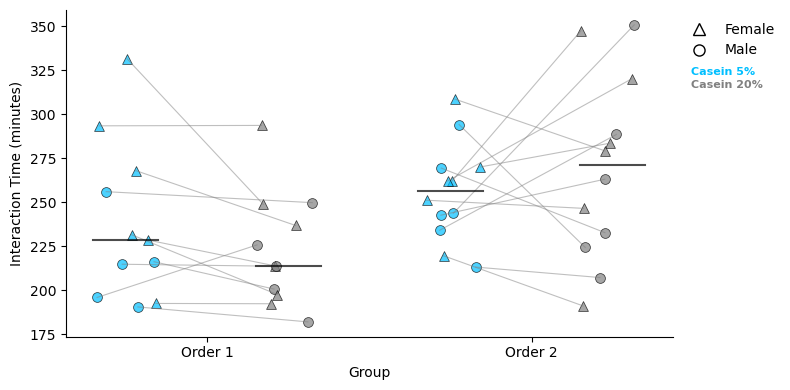

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Load the dataset
file_path = '../results/FIVE/SCATTER_PLOTS/INTERACTION_PER_PHASE/mice_interaction_times_Updated.csv'  
data = pd.read_csv(file_path)

# Grouping data by order and ignoring the grain phase
nrpr_order1_data = data[data['order'] == 1]
prnr_order2_data = data[data['order'] == 2]

# Separate interaction times for PR and NR phases
nrpr_order1_pr_interaction = nrpr_order1_data['PR'].values
nrpr_order1_nr_interaction = nrpr_order1_data['NR'].values
prnr_order2_pr_interaction = prnr_order2_data['PR'].values
prnr_order2_nr_interaction = prnr_order2_data['NR'].values

# Prepare data for plotting
interaction_data = [
    nrpr_order1_pr_interaction, nrpr_order1_nr_interaction,
    prnr_order2_pr_interaction, prnr_order2_nr_interaction
]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]

# Define plot settings
colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}
group_positions = {"Order 1": 0, "Order 2": 0.2}

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 4))
jitter_strength = 0.02

# Plot combined data points with gender-specific markers
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = interaction_data[i * 2]   # PR data for each order
    nr_data = interaction_data[i * 2 + 1]  # NR data for each order

    # Apply jitter to x-positions and assign markers based on sex
    pr_x = [group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in pr_data]
    nr_x = [group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in nr_data]
    
    # Draw line connecting PR and NR for each combined data point
    for j in range(len(pr_data)):
        ax.plot([pr_x[j], nr_x[j]], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot individual data points with markers for combined data
        marker = '^' if j % 2 == 0 else 'o'  # Alternate marker for visualization within combined data
        sns.scatterplot(x=[pr_x[j]], y=[pr_data[j]], color=colors["PR"], marker=marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x[j]], y=[nr_data[j]], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = interaction_data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend with combined markers for gender
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# Add text labels for PR and NR phases
plt.text(1.03, 0.8, 'Casein 5%', color='deepskyblue', transform=ax.transAxes, fontsize=8, fontweight='bold')
plt.text(1.03, 0.76, 'Casein 20%', color='grey', transform=ax.transAxes, fontsize=8, fontweight='bold')

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Interaction Time (minutes)")
sns.despine()
plt.tight_layout()
plt.show()


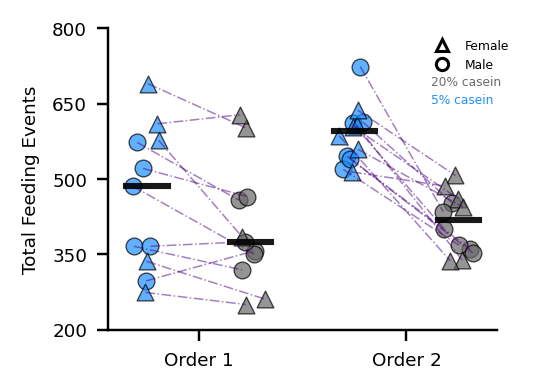

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Load the dataset
file_path = '../results/FIVE/SCATTER_PLOTS/SUM_OF_FEEDING_COMPONENTS/TOTAL_FEEDING_EVENTS.csv'
data = pd.read_csv(file_path)

# Separate data by order
nrpr_order1_data = data[data['Order'] == 1]
prnr_order2_data = data[data['Order'] == 2]

# Extract feeding data for plotting
nrpr_order1_pr = nrpr_order1_data['Total PR Parameters'].values
nrpr_order1_nr = nrpr_order1_data['Total NR Parameters'].values
prnr_order2_pr = prnr_order2_data['Total PR Parameters'].values
prnr_order2_nr = prnr_order2_data['Total NR Parameters'].values

# Prepare data for plotting
feeding_totals = [
    nrpr_order1_pr, nrpr_order1_nr,
    prnr_order2_pr, prnr_order2_nr
]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Spacing between PR and NR
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Adjusted for minimal gap
jitter_strength = 0.015  # Reduced jitter for clarity

# Create the figure
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=220)

# Plot data points with markers for sex and diet phase
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = feeding_totals[i * 2]   # PR data for each order
    nr_data = feeding_totals[i * 2 + 1]  # NR data for each order
    sex_data_pr = nrpr_order1_data['Sex'].values if label == "Order 1" else prnr_order2_data['Sex'].values

    # Apply jitter to x-positions and assign markers based on sex
    pr_x = [group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in pr_data]
    nr_x = [group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in nr_data]

    # Draw line connecting PR and NR for each combined data point
    for j in range(len(pr_data)):
        ax.plot([pr_x[j], nr_x[j]], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with markers based on sex
        sex_marker = '^' if sex_data_pr[j] == 'F' else 'o'  # Triangle for females, circle for males
        sns.scatterplot(x=[pr_x[j]], y=[pr_data[j]], color=colors["PR"], marker=sex_marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x[j]], y=[nr_data[j]], color=colors["NR"], marker=sex_marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = feeding_totals[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customize legend with markers for male and female
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
]
ax.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(0.8, 1), frameon=False, fontsize=4)

# Add text labels for PR and NR phases
ax.text(0.83, 0.75, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
ax.text(0.83, 0.81, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=6)
plt.yticks(fontsize=6)

# Add more y-ticks
current_yticks = ax.get_yticks()
new_yticks = np.linspace(current_yticks[0], current_yticks[-1], len(current_yticks) + 1)
plt.yticks(new_yticks, fontsize=6)

plt.xlabel("")
plt.ylabel("Total Feeding Events", fontsize=6)
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig("../plots/NEW_MEAL_PLOTS/scatter_plot_TOTAL_FEEDING_EVENTS.png", bbox_inches='tight', dpi=220)


# Below , plotting preference of NR pellets in two orders, not going to use it in the paper

11 items in output dictionary
12 items in output dictionary


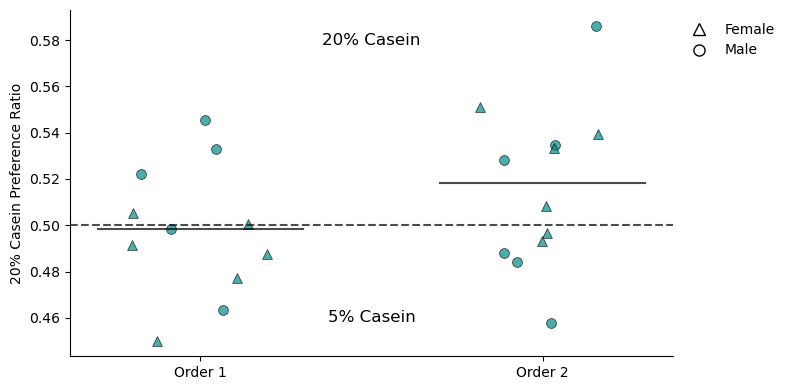

In [125]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Combine male and female data for PR and NR phases within each order
nrpr_order1_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 1})
prnr_order2_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 2})

# Sum pellets per day for each order and phase
nrpr_order1_pr_pellets = [sum(pellets) for pellets in nrpr_order1_data[0]]
nrpr_order1_nr_pellets = [sum(pellets) for pellets in nrpr_order1_data[1]]
prnr_order2_pr_pellets = [sum(pellets) for pellets in prnr_order2_data[0]]
prnr_order2_nr_pellets = [sum(pellets) for pellets in prnr_order2_data[1]]

# Calculate preference ratios for NR (Total NR / (Total NR + Total PR))
nrpr_order1_ratio = [
    nr / (nr + pr) if (nr + pr) > 0 else 0 for nr, pr in zip(nrpr_order1_nr_pellets, nrpr_order1_pr_pellets)
]
prnr_order2_ratio = [
    nr / (nr + pr) if (nr + pr) > 0 else 0 for nr, pr in zip(prnr_order2_nr_pellets, prnr_order2_pr_pellets)
]

# Prepare data for plotting
preference_ratios = [nrpr_order1_ratio, prnr_order2_ratio]
group_labels = ["Order 1", "Order 2"]
colors = {"NR": "darkcyan", "PR": "grey"}
group_positions = {"Order 1": 0, "Order 2": 0.1}
jitter_strength = 0.02

# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Plot NR preference ratios with markers for sex
for i, label in enumerate(group_labels):
    ratios = preference_ratios[i]
    # Apply jitter to x-positions
    x_positions = [group_positions[label] + np.random.uniform(-jitter_strength, jitter_strength) for _ in ratios]

    # Draw each data point with alternating markers for males and females
    for j, ratio in enumerate(ratios):
        marker = '^' if j % 2 == 0 else 'o'  # Triangle for females, circle for males
        sns.scatterplot(x=[x_positions[j]], y=[ratio], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each order's NR preference
for group, pos in group_positions.items():
    relevant_data = preference_ratios[group_labels.index(group)]
    median_value = np.median(relevant_data)
    ax.plot([pos - 0.03, pos + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend for male and female markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# Reference line at y=0.5 indicating no preference
plt.axhline(0.5, ls='--', color='black', linewidth=1.5, alpha=0.7)


# Add annotations for the y-axis
plt.text(0.5, 0.9, "20% Casein", fontsize=12, ha='center', transform=plt.gca().transAxes, color='black')
plt.text(0.5, 0.1, "5% Casein", fontsize=12, ha='center', transform=plt.gca().transAxes, color='black')

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]], ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("")
plt.ylabel("20% Casein Preference Ratio")
sns.despine()
plt.tight_layout()
plt.show()


11 items in output dictionary
12 items in output dictionary


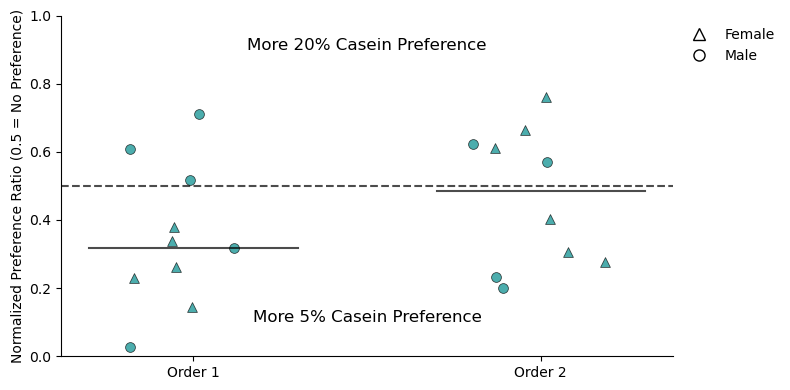

In [127]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Combine male and female data for PR and NR phases within each order
nrpr_order1_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 1})
prnr_order2_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 2})

# Sum pellets per day for each order and phase
nrpr_order1_pr_pellets = [sum(pellets) for pellets in nrpr_order1_data[0]]
nrpr_order1_nr_pellets = [sum(pellets) for pellets in nrpr_order1_data[1]]
prnr_order2_pr_pellets = [sum(pellets) for pellets in prnr_order2_data[0]]
prnr_order2_nr_pellets = [sum(pellets) for pellets in prnr_order2_data[1]]

# Calculate preference ratios for NR (Total NR / (Total NR + Total PR))
nrpr_order1_ratio = [
    nr / (nr + pr) if (nr + pr) > 0 else 0.5 for nr, pr in zip(nrpr_order1_nr_pellets, nrpr_order1_pr_pellets)
]
prnr_order2_ratio = [
    nr / (nr + pr) if (nr + pr) > 0 else 0.5 for nr, pr in zip(prnr_order2_nr_pellets, prnr_order2_pr_pellets)
]

# Get min and max of the original range
original_min, original_max = 0.46, 0.58

# Normalize preference ratios to fit between 0 and 1
def normalize(value, min_val=original_min, max_val=original_max):
    return (value - min_val) / (max_val - min_val)

nrpr_order1_ratio_scaled = [normalize(ratio) for ratio in nrpr_order1_ratio]
prnr_order2_ratio_scaled = [normalize(ratio) for ratio in prnr_order2_ratio]

# Prepare data for plotting
preference_ratios = [nrpr_order1_ratio_scaled, prnr_order2_ratio_scaled]
group_labels = ["Order 1", "Order 2"]
colors = {"NR": "darkcyan", "PR": "grey"}
group_positions = {"Order 1": 0, "Order 2": 0.1}
jitter_strength = 0.02

# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Plot NR preference ratios with markers for sex
for i, label in enumerate(group_labels):
    ratios = preference_ratios[i]
    x_positions = [group_positions[label] + np.random.uniform(-jitter_strength, jitter_strength) for _ in ratios]

    for j, ratio in enumerate(ratios):
        marker = '^' if j % 2 == 0 else 'o'  # Triangle for females, circle for males
        sns.scatterplot(x=[x_positions[j]], y=[ratio], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each order's NR preference
for group, pos in group_positions.items():
    relevant_data = preference_ratios[group_labels.index(group)]
    median_value = np.median(relevant_data)
    ax.plot([pos - 0.03, pos + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend for male and female markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# Reference line at y=0.5 indicating no preference in new scale
plt.axhline(0.5, ls='--', color='black', linewidth=1.5, alpha=0.7)

# Set y-axis from 0 to 1
ax.set_ylim(0, 1)

# Adjust text annotations for new scale
plt.text(0.5, 0.9, "More 20% Casein Preference", fontsize=12, ha='center', transform=plt.gca().transAxes, color='black')
plt.text(0.5, 0.1, "More 5% Casein Preference", fontsize=12, ha='center', transform=plt.gca().transAxes, color='black')

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]], ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("")
plt.ylabel("Normalized Preference Ratio (0.5 = No Preference)")
sns.despine()
plt.tight_layout()
plt.show()


In [49]:
import pandas as pd


mouse_ids_order1 = list(mice.keys())[:len(nrpr_order1_pr_pellets)]
mouse_ids_order2 = list(mice.keys())[len(nrpr_order1_pr_pellets):]

# Create data for Order 1 with NR preference ratios
order1_data = pd.DataFrame({
    "mouse_id": mouse_ids_order1,
    "sex": ["F" if i % 2 == 0 else "M" for i in range(len(mouse_ids_order1))],
    "order": [1] * len(mouse_ids_order1),
    "preference_ratio": nrpr_order1_ratio
})

# Create data for Order 2 with NR preference ratios
order2_data = pd.DataFrame({
    "mouse_id": mouse_ids_order2,
    "sex": ["F" if i % 2 == 0 else "M" for i in range(len(mouse_ids_order2))],
    "order": [2] * len(mouse_ids_order2),
    "preference_ratio": prnr_order2_ratio
})

# Combine Order 1 and Order 2 data
combined_data = pd.concat([order1_data, order2_data], ignore_index=True)

# Save to CSV
output_file_path = "..//results//preference_ratios.csv"
combined_data.to_csv(output_file_path, index=False)

print(f"Data saved to {output_file_path}")


Data saved to ..//results//preference_ratios.csv


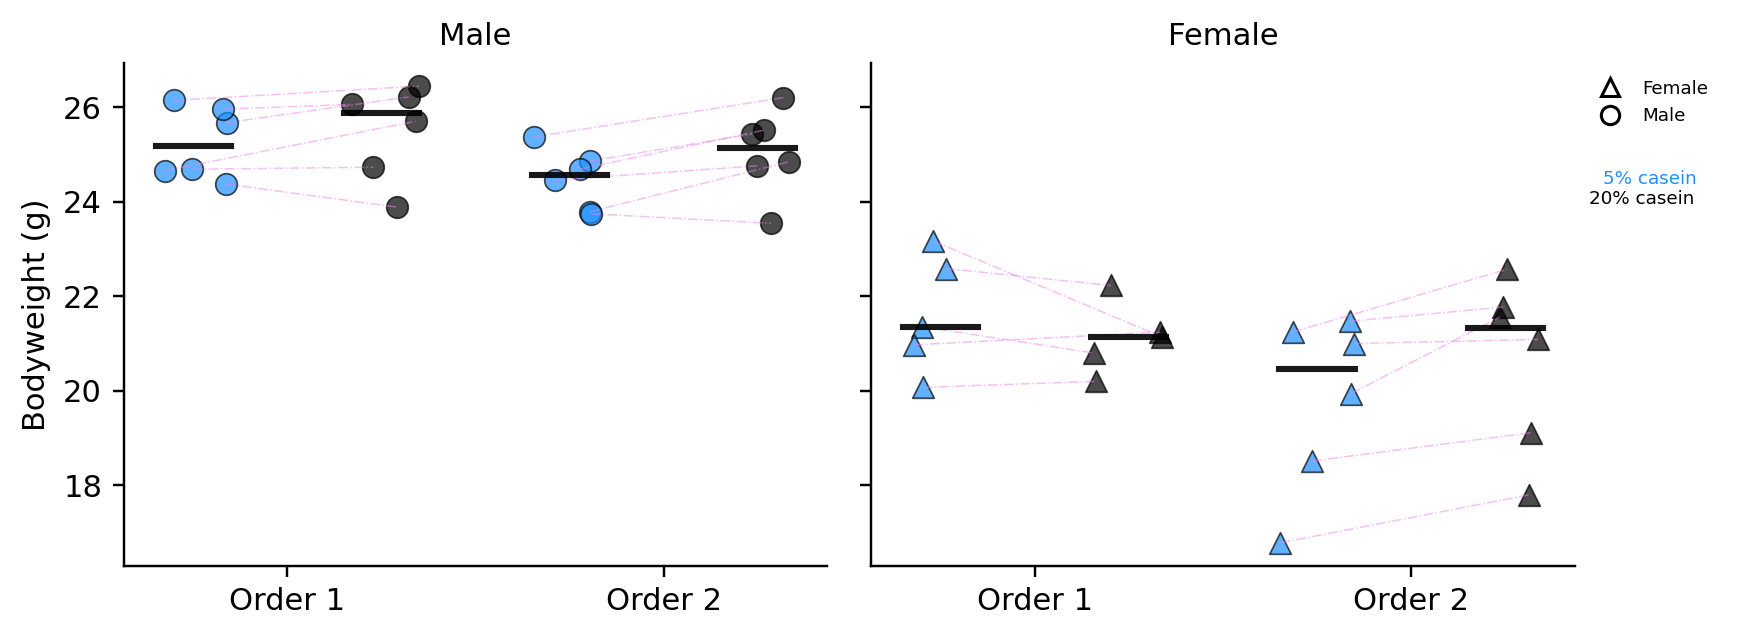

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# Load your data
file_path = '../results/FIVE/SCATTER_PLOTS/BODYWEIGHT/AV_BODYWEIGHT_PER_PHASE.csv'
data = pd.read_csv(file_path)

# Define plot settings
colors = {"PR": "dodgerblue", "NR": "black"}
markers = {"M": "o", "F": "^"}
offsets = {"PR": -0.05, "NR": 0.05}
group_positions = {
    "Order 1": 0, "Order 2": 0.2
}
jitter_strength = 0.02

# Create the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=220, sharey=True)
axes[0].set_title("Male", fontsize=10)
axes[1].set_title("Female", fontsize=10)

# Plot male and female data separately
for sex, ax in zip(["M", "F"], axes):
    for order, group_data in data[data['Sex'] == sex].groupby('Order'):
        group_label = f"Order {order}"
        pr_x = [group_positions[group_label] + offsets["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['PR']]
        nr_x = [group_positions[group_label] + offsets["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['NR']]

        # Draw connecting lines for PR and NR values
        for i in range(len(group_data)):
            ax.plot([pr_x[i], nr_x[i]], [group_data['PR'].iloc[i], group_data['NR'].iloc[i]], 
                    color='violet', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Scatterplot for PR values
        sns.scatterplot(x=pr_x, y=group_data['PR'], color=colors["PR"], 
                        marker=markers[sex], s=50, alpha=0.7, edgecolor="black", label=None, ax=ax)

        # Scatterplot for NR values
        sns.scatterplot(x=nr_x, y=group_data['NR'], color=colors["NR"], 
                        marker=markers[sex], s=50, alpha=0.7, edgecolor="black", label=None, ax=ax)

        # Add median lines for each phase
        for phase in ["PR", "NR"]:
            median_value = group_data[phase].median()
            x_val = group_positions[group_label] + offsets[phase]
            ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customise plot appearance
for ax in axes:
    ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]])
    ax.set_xticklabels(["Order 1", "Order 2"], fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Bodyweight (g)", fontsize=10)
    sns.despine(ax=ax)

# Add legend for sex markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=6, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=6, label='Male', fillstyle='none')
]
axes[1].legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(1, 1), frameon=False, fontsize=6)

# Add text labels for phases
axes[1].text(1.04, 0.76, '5% casein', color='dodgerblue', transform=axes[1].transAxes, fontsize=6)
axes[1].text(1.02, 0.72, '20% casein', color='black', transform=axes[1].transAxes, fontsize=6)

plt.tight_layout()
plt.show()

# Save the figure
#fig.savefig("../plots/NEW_MEAL_PLOTS/connected_bodyweight_scatter_plot_split_sex.png", bbox_inches='tight', dpi=300)


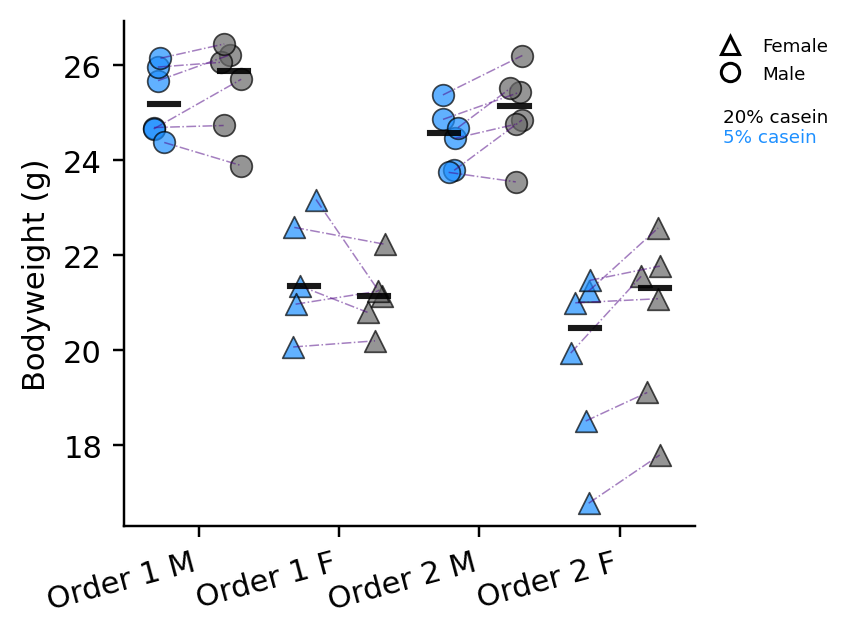

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# Load your data
file_path = '../results/FIVE/SCATTER_PLOTS/BODYWEIGHT/AV_BODYWEIGHT_PER_PHASE.csv'
data = pd.read_csv(file_path)

# Define plot settings
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}
offsets = {"PR": -0.05, "NR": 0.05}
group_positions = {
    "Order 1 M": 0, "Order 1 F": 0.2,
    "Order 2 M": 0.4, "Order 2 F": 0.6
}
jitter_strength = 0.02

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=220)

# Plot each group separately
for (order, sex), group_data in data.groupby(['Order', 'Sex']):
    group_label = f"Order {order} {sex}"
    pr_x = [group_positions[group_label] + offsets["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['PR']]
    nr_x = [group_positions[group_label] + offsets["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['NR']]

    # Draw connecting lines for PR and NR values
    for i in range(len(group_data)):
        ax.plot([pr_x[i], nr_x[i]], [group_data['PR'].iloc[i], group_data['NR'].iloc[i]], 
                color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

    # Scatterplot for PR values
    sns.scatterplot(x=pr_x, y=group_data['PR'], color=colors["PR"], 
                    marker=markers[sex], s=50, alpha=0.7, edgecolor="black", label=None)

    # Scatterplot for NR values
    sns.scatterplot(x=nr_x, y=group_data['NR'], color=colors["NR"], 
                    marker=markers[sex], s=50, alpha=0.7, edgecolor="black", label=None)

# Add median lines for each group
for (order, sex), group_data in data.groupby(['Order', 'Sex']):
    group_label = f"Order {order} {sex}"
    for phase in ["PR", "NR"]:
        median_value = group_data[phase].median()
        x_val = group_positions[group_label] + offsets[phase]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customise plot appearance
ax.set_xticks([group_positions["Order 1 M"], group_positions["Order 1 F"], 
               group_positions["Order 2 M"], group_positions["Order 2 F"]])
ax.set_xticklabels(["Order 1 M", "Order 1 F", "Order 2 M", "Order 2 F"], fontsize=10, rotation=15, ha="right")
ax.set_xlabel("")
ax.set_ylabel("Bodyweight (g)", fontsize=10)
sns.despine()

# Add legend for sex markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=6, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=6, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(1, 1), frameon=False, fontsize=6)

# Add text labels for phases
plt.text(1.05, 0.76, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=6)
plt.text(1.05, 0.80, '20% casein', color='black', transform=ax.transAxes, fontsize=6)

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig("../plots/NEW_MEAL_PLOTS/connected_bodyweight_scatter_plot.png", bbox_inches='tight', dpi=220)


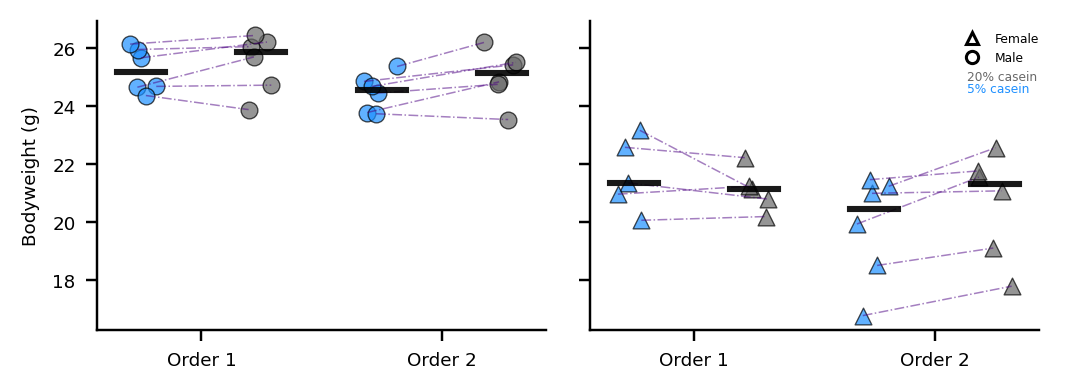

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# Load your data
file_path = '../results/FIVE/SCATTER_PLOTS/BODYWEIGHT/AV_BODYWEIGHT_PER_PHASE.csv'
data = pd.read_csv(file_path)

# Define plot settings
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}
offsets = {"PR": -0.05, "NR": 0.05}
group_positions = {
    "Order 1": 0, "Order 2": 0.2  # Adjusted for consistency with other plots
}
jitter_strength = 0.015  # Reduced jitter to match other plots







# Create the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(5, 1.88), dpi=220, sharey=True)
axes[0].set_title("", fontsize=6)
axes[1].set_title("", fontsize=6)

# Plot male and female data separately
for sex, ax in zip(["M", "F"], axes):
    for order, group_data in data[data['Sex'] == sex].groupby('Order'):
        group_label = f"Order {order}"
        pr_x = [group_positions[group_label] + offsets["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['PR']]
        nr_x = [group_positions[group_label] + offsets["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['NR']]

        # Draw connecting lines for PR and NR values
        for i in range(len(group_data)):
            ax.plot([pr_x[i], nr_x[i]], [group_data['PR'].iloc[i], group_data['NR'].iloc[i]], 
                    color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Scatterplot for PR values
        sns.scatterplot(x=pr_x, y=group_data['PR'], color=colors["PR"], 
                        marker=markers[sex], s=30, alpha=0.7, edgecolor="black", ax=ax)

        # Scatterplot for NR values
        sns.scatterplot(x=nr_x, y=group_data['NR'], color=colors["NR"], 
                        marker=markers[sex], s=30, alpha=0.7, edgecolor="black", ax=ax)

        # Add median lines for each phase
        for phase in ["PR", "NR"]:
            median_value = group_data[phase].median()
            x_val = group_positions[group_label] + offsets[phase]
            ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customise plot appearance
for ax in axes:
    ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]])
    ax.set_xticklabels(["Order 1", "Order 2"], fontsize=6)
    ax.set_xlabel("")
    ax.set_ylabel("Bodyweight (g)", fontsize=6)
    ax.tick_params(axis='y', labelsize=6)  # Set y-ticks font size
    sns.despine(ax=ax)

# Add legend for sex markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
]
axes[1].legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(0.8, 1), frameon=False, fontsize=4)

# Add text labels for phases
axes[1].text(0.84, 0.77, '5% casein', color='dodgerblue', transform=axes[1].transAxes, fontsize=4)
axes[1].text(0.84, 0.81, '20% casein', color='dimgray', transform=axes[1].transAxes, fontsize=4)

plt.tight_layout()
plt.show()

#fig.savefig("../plots/NEW_MEAL_PLOTS/connected_bodyweight_scatter_plot.png", bbox_inches='tight', dpi=220)


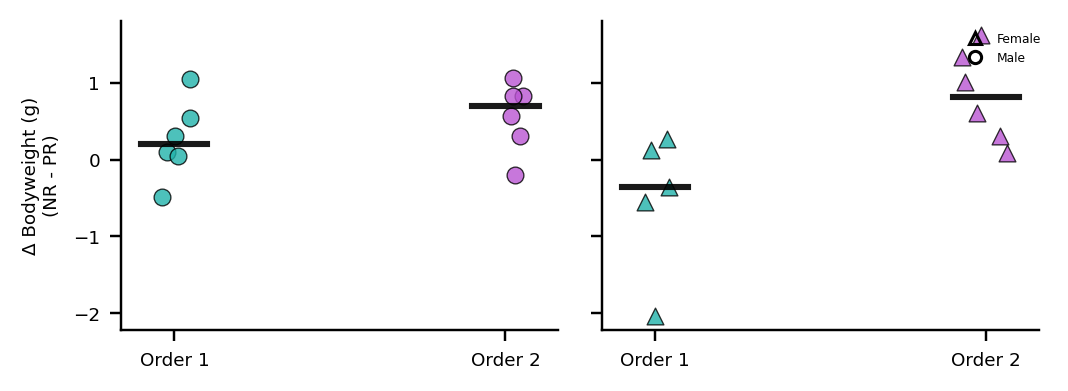

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# Load your data
file_path = '../results/FIVE/SCATTER_PLOTS/BODYWEIGHT/AV_BODYWEIGHT_PER_PHASE.csv'
data = pd.read_csv(file_path)

# Calculate delta bodyweight (NR - PR)
data["delta_BW"] = data["NR"] - data["PR"]

# Define plot settings
colors = {"Order 1": "lightseagreen", "Order 2": "mediumorchid"}
markers = {"M": "o", "F": "^"}
jitter_strength = 0.015  # Jitter to spread points a bit horizontally
group_positions = {"Order 1": 0, "Order 2": 0.2}

# Create the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(5, 1.88), dpi=220, sharey=True)
axes[0].set_title("", fontsize=6)
axes[1].set_title("", fontsize=6)

# Plot male and female delta BW separately
for sex, ax in zip(["M", "F"], axes):
    for order, group_data in data[data["Sex"] == sex].groupby("Order"):
        group_label = f"Order {order}"
        x_jitter = [group_positions[group_label] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data["delta_BW"]]

        # Scatter plot of delta BW
        sns.scatterplot(
            x=x_jitter, y=group_data["delta_BW"],
            color=colors[group_label],
            marker=markers[sex], s=30, alpha=0.8, edgecolor="black", ax=ax
        )

        # Add median line
        median_val = group_data["delta_BW"].median()
        ax.plot(
            [group_positions[group_label] - 0.02, group_positions[group_label] + 0.02],
            [median_val, median_val],
            color="black", linewidth=2, alpha=0.9
        )

# Customise plot appearance
for ax in axes:
    ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]])
    ax.set_xticklabels(["Order 1", "Order 2"], fontsize=6)
    ax.set_xlabel("")
    ax.set_ylabel("Δ Bodyweight (g)\n(NR - PR)", fontsize=6)
    ax.tick_params(axis="y", labelsize=6)
    sns.despine(ax=ax)

# Add legend for sex markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
]
axes[1].legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(0.8, 1), frameon=False, fontsize=4)

plt.tight_layout()
plt.show()

#fig.savefig("../plots/NEW_MEAL_PLOTS/delta_bodyweight_scatter_plot.png", bbox_inches='tight', dpi=220)


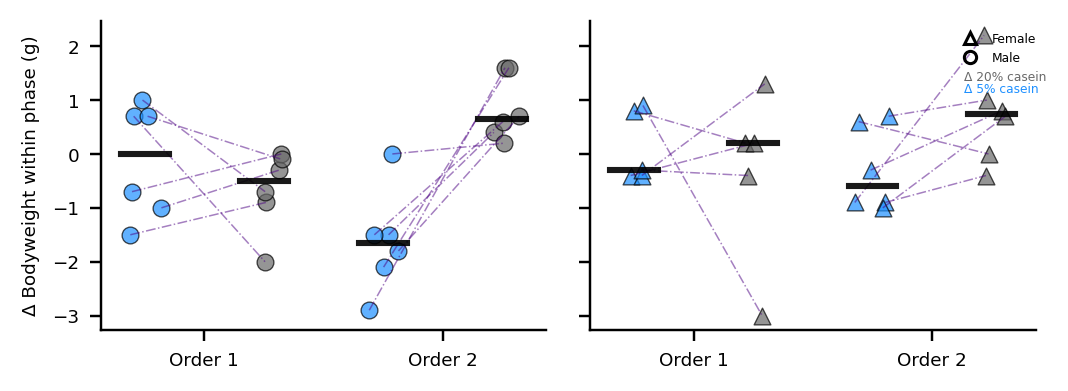

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D


file_path = '../results/FIVE/LINE_PLOTS/Bodyweight/BODYWEIGHT.csv'
data = pd.read_csv(file_path)

# Calculate ΔBW within each phase
data["delta_PR"] = data["PR6"] - data["PR0"]
data["delta_NR"] = data["NR6"] - data["NR0"]

# Define plot settings
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}
offsets = {"PR": -0.05, "NR": 0.05}
group_positions = {
    "Order 1": 0, "Order 2": 0.2  # Adjusted for consistency with other plots
}
jitter_strength = 0.015


fig, axes = plt.subplots(1, 2, figsize=(5, 1.88), dpi=220, sharey=True)
axes[0].set_title("", fontsize=6)
axes[1].set_title("", fontsize=6)


for sex, ax in zip(["M", "F"], axes):
    for order, group_data in data[data['Sex'] == sex].groupby('Order'):
        group_label = f"Order {order}"
        pr_x = [group_positions[group_label] + offsets["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['delta_PR']]
        nr_x = [group_positions[group_label] + offsets["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['delta_NR']]

        # Draw connecting lines for PR and NR ΔBW
        for i in range(len(group_data)):
            ax.plot([pr_x[i], nr_x[i]], [group_data['delta_PR'].iloc[i], group_data['delta_NR'].iloc[i]], 
                    color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Scatterplot for PR ΔBW
        sns.scatterplot(x=pr_x, y=group_data['delta_PR'], color=colors["PR"], 
                        marker=markers[sex], s=30, alpha=0.7, edgecolor="black", ax=ax)

        # Scatterplot for NR ΔBW
        sns.scatterplot(x=nr_x, y=group_data['delta_NR'], color=colors["NR"], 
                        marker=markers[sex], s=30, alpha=0.7, edgecolor="black", ax=ax)

        # Add median lines for each phase
        for phase in ["PR", "NR"]:
            median_value = group_data[f'delta_{phase}'].median()
            x_val = group_positions[group_label] + offsets[phase]
            ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Customise plot appearance
for ax in axes:
    ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]])
    ax.set_xticklabels(["Order 1", "Order 2"], fontsize=6)
    ax.set_xlabel("")
    ax.set_ylabel("Δ Bodyweight within phase (g)", fontsize=6)
    ax.tick_params(axis='y', labelsize=6)
    sns.despine(ax=ax)

# Add legend for sex markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
]
axes[1].legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(0.8, 1), frameon=False, fontsize=4)

# Add text labels for phases
axes[1].text(0.84, 0.77, 'Δ 5% casein', color='dodgerblue', transform=axes[1].transAxes, fontsize=4)
axes[1].text(0.84, 0.81, 'Δ 20% casein', color='dimgray', transform=axes[1].transAxes, fontsize=4)

plt.tight_layout()
plt.show()


# fig.savefig("../plots/NEW_MEAL_PLOTS/connected_delta_bodyweight_scatter_plot.png", bbox_inches='tight', dpi=220)


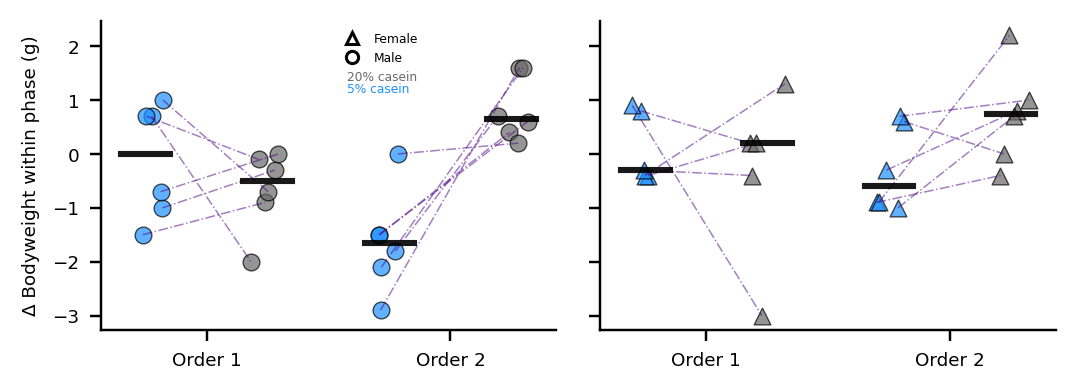

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D


file_path = '../results/FIVE/LINE_PLOTS/Bodyweight/BODYWEIGHT.csv'
data = pd.read_csv(file_path)

# Compute ΔBW per phase
data["delta_PR"] = data["PR6"] - data["PR0"]
data["delta_NR"] = data["NR6"] - data["NR0"]

# Save ΔBW data to CSV for statistics
output_csv_path = '../results/FIVE/LINE_PLOTS/Bodyweight/DELTA_BODYWEIGHT_PER_PHASE.csv'
data[["Mouse", "Sex", "Order", "delta_PR", "delta_NR"]].to_csv(output_csv_path, index=False)

# Plot settings
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}
offsets = {"PR": -0.05, "NR": 0.05}
group_positions = {"Order 1": 0, "Order 2": 0.2}
jitter_strength = 0.015

fig, axes = plt.subplots(1, 2, figsize=(5, 1.88), dpi=220, sharey=True)
axes[0].set_title("", fontsize=6)
axes[1].set_title("", fontsize=6)

# Plot data
for sex, ax in zip(["M", "F"], axes):
    for order, group_data in data[data['Sex'] == sex].groupby('Order'):
        group_label = f"Order {order}"
        pr_x = [group_positions[group_label] + offsets["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['delta_PR']]
        nr_x = [group_positions[group_label] + offsets["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['delta_NR']]

        # Connect PR and NR points
        for i in range(len(group_data)):
            ax.plot([pr_x[i], nr_x[i]], [group_data['delta_PR'].iloc[i], group_data['delta_NR'].iloc[i]], 
                    color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # PR points
        sns.scatterplot(x=pr_x, y=group_data['delta_PR'], color=colors["PR"], 
                        marker=markers[sex], s=30, alpha=0.7, edgecolor="black", ax=ax)

        # NR points
        sns.scatterplot(x=nr_x, y=group_data['delta_NR'], color=colors["NR"], 
                        marker=markers[sex], s=30, alpha=0.7, edgecolor="black", ax=ax)

        # Median lines
        for phase in ["PR", "NR"]:
            median_value = group_data[f'delta_{phase}'].median()
            x_val = group_positions[group_label] + offsets[phase]
            ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# Format axes
for ax in axes:
    ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]])
    ax.set_xticklabels(["Order 1", "Order 2"], fontsize=6)
    ax.set_xlabel("")
    ax.set_ylabel("Δ Bodyweight within phase (g)", fontsize=6)
    ax.tick_params(axis='y', labelsize=6)
    sns.despine(ax=ax)

custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
]
axes[0].legend(handles=custom_lines, title="", loc="upper left", bbox_to_anchor=(0.5, 1), frameon=False, fontsize=4)

axes[0].text(0.54, 0.77, '5% casein', color='dodgerblue', transform=axes[0].transAxes, fontsize=4)
axes[0].text(0.54, 0.81, '20% casein', color='dimgray', transform=axes[0].transAxes, fontsize=4)

plt.tight_layout()
plt.show()

# Save plot
#fig.savefig("../plots/NEW_MEAL_PLOTS/connected_delta_bodyweight_scatter_plot.png", bbox_inches='tight', dpi=220)


# Cell below plotting CE breakpoints

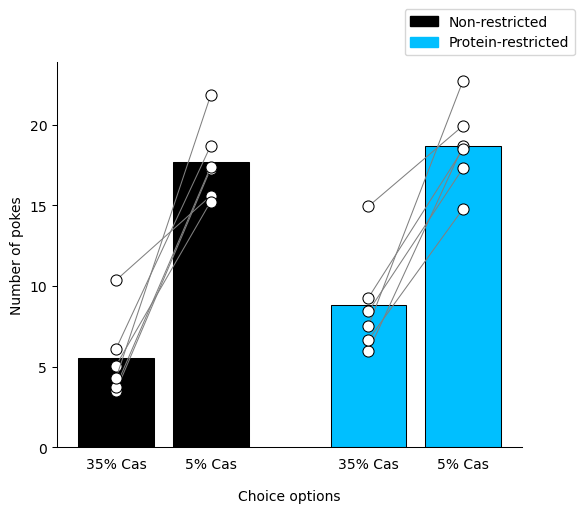

In [74]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import trompy as tp

DATA_FOLDER = "..\\data"
df = pd.read_csv(os.path.join(DATA_FOLDER, "FED001_042322_00.CSV"))

def tweak_fed(df):
    
    return (df
            .rename(columns={"MM:DD:YYYY hh:mm:ss": "t",
                             "InterPelletInterval": "ipi"})
            .assign(t=lambda df_: pd.to_datetime(df_.t))
            .set_index("t")
            .query("Event == 'Pellet'")
            .loc[:,"ipi"] # could use .loc[:,["ipi", "col2", "col5" etc]] to get mutliple columns, e.g. animal name etc
           )

pellets = tweak_fed(df) # could add animal name from metafile and diet and phase so these are returned in dataframe

# read in metafile and put pellets dataframe in keys of a dict
METAFILE = "..\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(METAFILE, sheetname="METAFILE")

ff_dict = {}
for row in rows:
    file, mouse, diet, mode, sex, order = row
    if (mode == "FF") and (diet in ["NR", "PR"]):
        key = "_".join([mouse, diet])
        ff_dict[key] = {}
        ff_dict[key]["mouse"] = mouse
        ff_dict[key]["diet"] = diet
        ff_dict[key]["sex"] = sex
        ff_dict[key]["pellets"] = tweak_fed(pd.read_csv(os.path.join(DATA_FOLDER, file)))
    
def make_ff_df(df, mouse, diet):
    """
    Takes df of pellets - time and IPIs - and returns row for collated df
    """
    out = pd.DataFrame.from_dict({"mouse": [mouse],
                                  "diet": [diet],
                                  "n_pellets": [len(df)],
                                  "n_meals": (df > 60).sum(),
                                  "session_time": (df.index[-1] - df.index[0]).total_seconds() / 60,
                                  "short_ipis": (df < 5).sum()
                                  })

    return (out
           .assign(meal_freq=lambda df_: 1 / (df_.session_time / df_.n_meals) * 60 * 24,
                   meal_size=lambda df_: df_.n_pellets / df_.n_meals,
                   )
           .astype({"diet": "category",
                    "n_pellets": "uint16",
                    "n_meals": "uint16"}))

ff = pd.DataFrame()

for key, val in ff_dict.items():
    
    pellets = val["pellets"]
    mouse = val["mouse"]
    diet = val["diet"]
    ff = pd.concat([ff, make_ff_df(pellets, mouse, diet)])
    
ff.reset_index(drop=True, inplace=True);
ff.groupby(by=["mouse", "diet"])

# read in metafile and put pellets dataframe in keys of a dict
METAFILE = "..\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(METAFILE, sheetname="METAFILE")

def tweak_eco(df, event="Left"):
    
    return (df
            .rename(columns={"MM:DD:YYYY hh:mm:ss": "t"})
            .assign(t=lambda df_: pd.to_datetime(df_.t))
            .set_index("t")
            .query("Event == @event")
            .loc[:,"FR"]           
           )

eco_dict = {}
for row in rows:
    file, mouse, diet, mode, sex, order = row
    if (mode == "ECO") and (diet in ["PR", "RICH"]):
        key = "_".join([mouse, diet])
        eco_dict[key] = {}
        eco_dict[key]["mouse"] = mouse
        eco_dict[key]["diet"] = diet
        eco_dict[key]["sex"] = sex
        eco_dict[key]["FR"] = tweak_eco(pd.read_csv(os.path.join(DATA_FOLDER, file)))
    



def get_FR_reset_index(df):
    
    return (df
            .reset_index()
            .query("FR == 1")
            .reset_index()
            ["index"]   
           )

def get_breakpoints(df):
    
    return (df
            .iloc[get_FR_reset_index(df)[1:] - 1]
           )

def make_eco_df(df, mouse, diet):
    """
    Takes df of FRs and returns row for collated df
    """
    out = pd.DataFrame.from_dict({"mouse": [mouse],
                                  "pellet_type": [diet],
                                  "n_pellets": [(df == 1).sum()],
                                  "breakpoint": [np.mean(get_breakpoints(df))]
                                 }
                                )

    return (out
           .astype({"pellet_type": "category",
                    "n_pellets": "uint16",
                    })
           )
                                  
eco_df = pd.DataFrame()

for key, val in eco_dict.items():
    
    fr = val["FR"]
    mouse = val["mouse"]
    diet = val["diet"]
    eco_df = pd.concat([eco_df, make_eco_df(fr, mouse, diet)])
    
eco_df.reset_index(drop=True, inplace=True);
eco_df = eco_df.assign(diet=["NR"] * 12 + ["PR"] * 12)



n_pellets = pd.pivot_table(eco_df, values="n_pellets", index=["mouse", "diet"], columns="pellet_type")
breakpoint = pd.pivot_table(eco_df, values="breakpoint", index=["mouse", "diet"], columns="pellet_type")
# meal_freq = pd.pivot_table(ff, values="meal_freq", index="mouse", columns="diet")




fed_cols = ["black", "black", "deepskyblue", "deepskyblue"]
f, ax = plt.subplots(ncols = 1,
                     figsize=(6,5),
                     gridspec_kw={"wspace": 0.9})


NR = breakpoint.xs("NR", level=1)
PR = breakpoint.xs("PR", level=1)

tp.barscatter([[NR.RICH, NR.PR],
               [PR.RICH, PR.PR]
              ],
              paired=True,
              barfacecolor=fed_cols,
              barfacecolor_option="individual",
              barlabels=["35% Cas", "5% Cas", "35% Cas", "5% Cas"],
              ax=ax);


ax.set_ylabel("Number of pokes")
ax.set_xlabel("Choice options", labelpad = 30)
#ax.axhline(5.5, color="magenta")




NR_patch = mpatches.Patch(color=fed_cols[0], label='Non-restricted')
PR_patch = mpatches.Patch(color=fed_cols[2], label='Protein-restricted')
ax.legend(handles=[NR_patch, PR_patch],
             bbox_to_anchor=(1, 1),
             bbox_transform=f.transFigure)

#f.savefig(fig_folder + "breakpoint.png")
#f.savefig(fig_folder + "breakpoint.tif")
#f.savefig(fig_folder + "breakpoint.pdf")

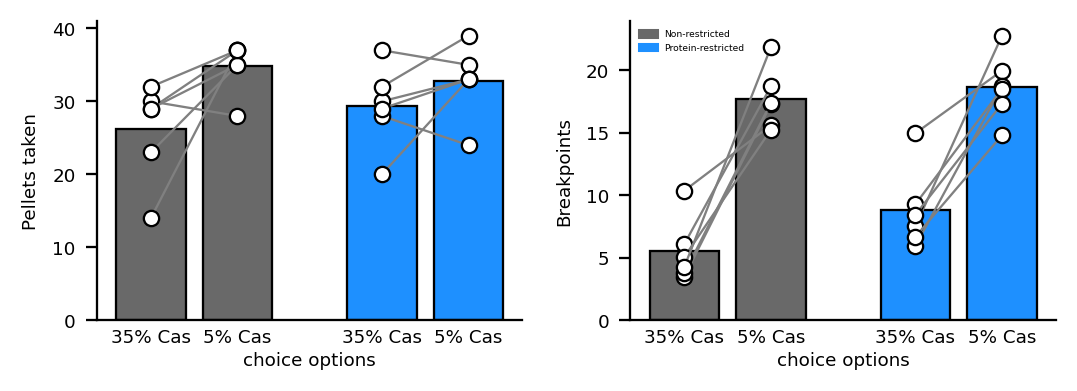

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import trompy as tp



# For the barscatter, extract rows for 'NR' and 'PR':
NR_break = breakpoint.xs("NR", level=1)  # Non-restricted subset
PR_break = breakpoint.xs("PR", level=1)  # Protein-restricted subset

NR_pell = n_pellets.xs("NR", level=1)
PR_pell = n_pellets.xs("PR", level=1)

# -----------------------------------------------------

# -----------------------------------------------------
fig, axes = plt.subplots(ncols=2, 
                         figsize=(5, 1.88),  #
                         dpi=220)

# -----------------------------------------------------
# 3) DEFINE THE COLOR SCHEME AND LEGEND PATCHES
#    Matching your scatter: NR = dimgray, PR = dodgerblue
# -----------------------------------------------------
fed_cols = ["dimgray", "dimgray", "dodgerblue", "dodgerblue"]
NR_patch = mpatches.Patch(color="dimgray", label='Non-restricted')
PR_patch = mpatches.Patch(color="dodgerblue", label='Protein-restricted')

# -----------------------------------------------------
# 4) FIRST SUBPLOT: BREAKPOINTS
# -----------------------------------------------------
ax_break = axes[1]

tp.barscatter([[NR_break.RICH, NR_break.PR],
               [PR_break.RICH, PR_break.PR]],
              paired=True,
              barfacecolor=fed_cols,
              barfacecolor_option="individual",
              barlabels=["35% Cas", "5% Cas", "35% Cas", "5% Cas"],
              ax=ax_break, fontsize=6, scattersize=50)

ax_break.set_ylabel("Breakpoints", fontsize=6)
ax_break.set_xlabel("choice options", fontsize=6, labelpad = 10)  # or ax_break.set_xlabel("Choice Options", ...)
ax_break.tick_params(labelsize=6)    # smaller tick labels

# Optionally, add a legend on this subplot:
ax_break.legend(handles=[NR_patch, PR_patch],
                loc="upper left",
                frameon=False,
                fontsize=3)

# -----------------------------------------------------
# 5) SECOND SUBPLOT: PELLETS
# -----------------------------------------------------
ax_pell = axes[0]

tp.barscatter([[NR_pell.RICH, NR_pell.PR],
               [PR_pell.RICH, PR_pell.PR]],
              paired=True,
             
              barfacecolor=fed_cols,
              barfacecolor_option="individual",
              barlabels=["35% Cas", "5% Cas", "35% Cas", "5% Cas"],
              ax=ax_pell, fontsize=6,scattersize=50)

ax_pell.set_ylabel("Pellets taken", fontsize=6)
ax_pell.set_xlabel("choice options", fontsize=6,  labelpad = 10)   # or ax_pell.set_xlabel("Choice Options", ...)
ax_pell.tick_params(labelsize=6)


# -----------------------------------------------------
# 6) FINAL STYLING AND SAVE
# -----------------------------------------------------
sns.despine(fig=fig)     # remove top/right spines
plt.tight_layout()
plt.show()

# Optionally save
# fig.savefig("combined_barscatter.png", bbox_inches='tight', dpi=220)


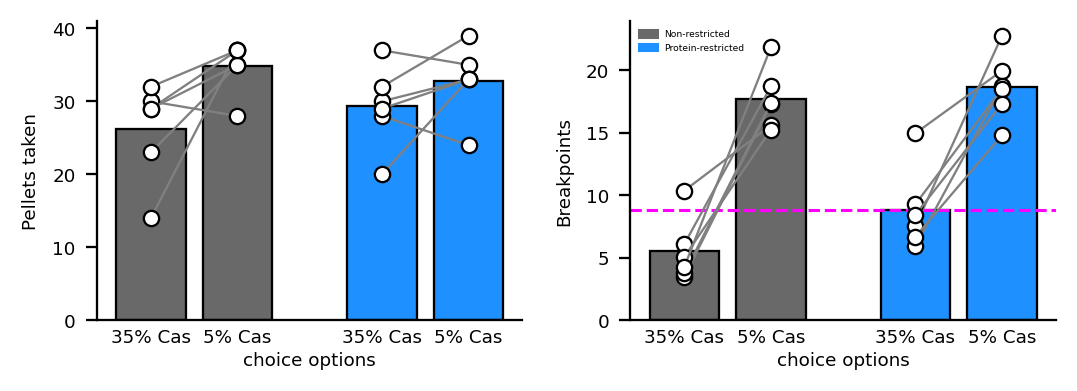

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import trompy as tp



# For the barscatter, extract rows for 'NR' and 'PR'
NR_break = breakpoint.xs("NR", level=1)  # Non-restricted subset
PR_break = breakpoint.xs("PR", level=1)  # Protein-restricted subset

NR_pell = n_pellets.xs("NR", level=1)
PR_pell = n_pellets.xs("PR", level=1)

# -----------------------------------------------------
# 2) SET UP THE FIGURE AND AXES
#    (Two side-by-side subplots)
# -----------------------------------------------------
fig, axes = plt.subplots(ncols=2, 
                         figsize=(5, 1.88),  # ~2.5" wide per subplot
                         dpi=220)

# -----------------------------------------------------
# 3) DEFINE THE COLOR SCHEME AND LEGEND PATCHES
#    (Matching your scatter: NR = dimgray, PR = dodgerblue)
# -----------------------------------------------------
fed_cols = ["dimgray", "dimgray", "dodgerblue", "dodgerblue"]
NR_patch = mpatches.Patch(color="dimgray", label='Non-restricted')
PR_patch = mpatches.Patch(color="dodgerblue", label='Protein-restricted')

# -----------------------------------------------------
# 4) FIRST SUBPLOT: BREAKPOINTS
# -----------------------------------------------------
ax_break = axes[1]

tp.barscatter([[NR_break.RICH, NR_break.PR],
               [PR_break.RICH, PR_break.PR]],
              paired=True,
              barfacecolor=fed_cols,
              barfacecolor_option="individual",
              barlabels=["35% Cas", "5% Cas", "35% Cas", "5% Cas"],
              ax=ax_break, fontsize=6, scattersize=50)

ax_break.set_ylabel("Breakpoints", fontsize=6)
ax_break.set_xlabel("choice options", fontsize=6, labelpad=10)
ax_break.tick_params(labelsize=6)

ax_break.legend(handles=[NR_patch, PR_patch],
                loc="upper left",
                frameon=False,
                fontsize=3)


NR_35 = NR_break.RICH.mean()  # "35% Cas" for non-restricted
PR_35 = PR_break.RICH.mean()  # "35% Cas" for protein-restricted
# Choose the higher of the two (or use one group if appropriate)
red_line_value = max(NR_35, PR_35)

# Draw a horizontal dashed red line across the full width of the axis
ax_break.axhline(y=red_line_value, color='magenta', linestyle='--', linewidth=1)

# -----------------------------------------------------
# 5) SECOND SUBPLOT: PELLETS
# -----------------------------------------------------
ax_pell = axes[0]

tp.barscatter([[NR_pell.RICH, NR_pell.PR],
               [PR_pell.RICH, PR_pell.PR]],
              paired=True,
              barfacecolor=fed_cols,
              barfacecolor_option="individual",
              barlabels=["35% Cas", "5% Cas", "35% Cas", "5% Cas"],
              ax=ax_pell, fontsize=6, scattersize=50)

ax_pell.set_ylabel("Pellets taken", fontsize=6)
ax_pell.set_xlabel("choice options", fontsize=6, labelpad=10)
ax_pell.tick_params(labelsize=6)

# (Optional: add legend here if you prefer)
# ax_pell.legend(handles=[NR_patch, PR_patch], loc="upper right", frameon=False, fontsize=4)

# -----------------------------------------------------
# 6) FINAL STYLING AND DISPLAY/SAVE
# -----------------------------------------------------
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

# Optionally, save your figure:
# fig.savefig("combined_barscatter.png", bbox_inches='tight', dpi=220)


In [81]:
print(NR_break)

pellet_type         PR       RICH
mouse                            
FEDXA01      17.277778   3.500000
FEDXA02      15.588235  10.363636
FEDXA03      17.388889   3.769231
FEDXA04      18.703704   6.103448
FEDXA05      15.235294   5.071429
FEDXA06      21.833333   4.290323


In [82]:
# Reset the index so that the MultiIndex becomes regular columns.
breakpoint_reset = breakpoint.reset_index()
n_pellets_reset = n_pellets.reset_index()

# Optionally, rename the 'diet' column to 'Order' if that is required:
breakpoint_reset = breakpoint_reset.rename(columns={'diet': 'Order'})
n_pellets_reset = n_pellets_reset.rename(columns={'diet': 'Order'})

# Save the dataframes to CSV files (modify file paths as needed)
breakpoint_reset.to_csv("breakpoints_data.csv", index=False)
n_pellets_reset.to_csv("pellets_data.csv", index=False)

ECO Metrics (one row per mouse & pellet choice):
      mouse pellet_type sex  order  n_pellets  avg_breakpoint
0   FEDXA01          PR   M    2.0        319       17.277778
1   FEDXA01        RICH   M    2.0         49        3.500000
2   FEDXA02          PR   M    2.0        275       15.588235
3   FEDXA02        RICH   M    2.0        119       10.363636
4   FEDXA03          PR   M    2.0        328       17.388889
5   FEDXA03        RICH   M    2.0         24        3.769231
6   FEDXA04          PR   M    2.0        257       18.703704
7   FEDXA04        RICH   M    2.0         90        6.103448
8   FEDXA05          PR   M    2.0        266       15.235294
9   FEDXA05        RICH   M    2.0         70        5.071429
10  FEDXA06          PR   M    2.0        417       21.833333
11  FEDXA06        RICH   M    2.0         68        4.290323
12  FEDXA07          PR   M    1.0        266       22.739130
13  FEDXA07        RICH   M    1.0        106        7.518519
14  FEDXA08          

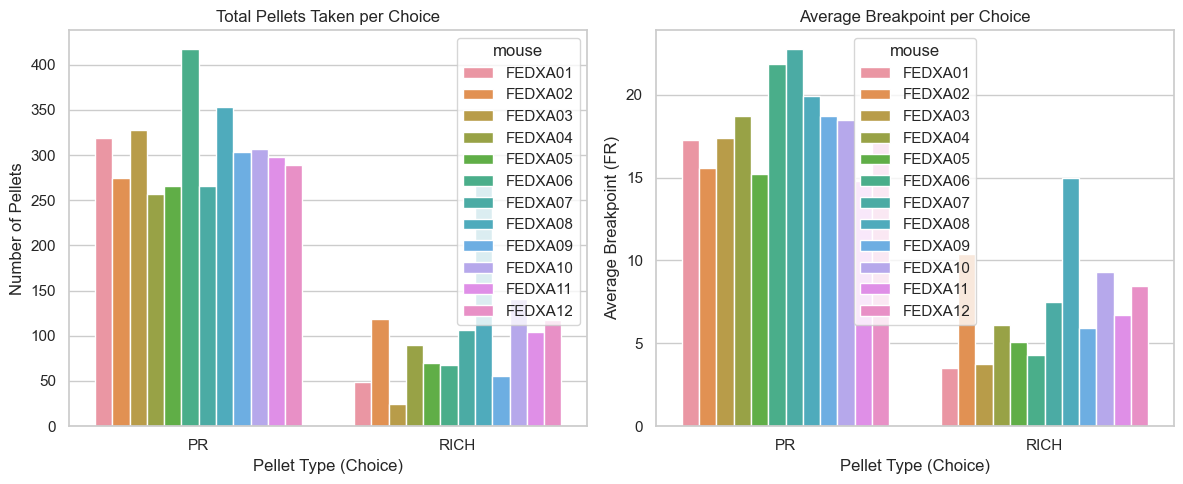

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import trompy as tp  

# ============================
# SETTINGS & FILE PATHS
# ============================
DATA_FOLDER = "../data"  # adjust if needed
METAFILE = "../FEDProtein_METAFILE.xls"

# ============================
# READ THE METAFILE
# ============================

#   file, mouse, diet, mode, sex, order
rows, header = tp.metafilereader(METAFILE, sheetname="METAFILE")

# ============================
# ECO PIPELINE FUNCTIONS
# ============================
def tweak_eco(df, event="Left"):
    """
    Process an ECO file:
      - Rename the timestamp column,
      - Convert it to datetime and set as index,
      - Filter for the specified event (default "Left"),
      - Return the 'FR' column.
      
    (We assume that the file also contains a column "Pellet_Count" that we won't touch here.)
    """
    return (df
            .rename(columns={"MM:DD:YYYY hh:mm:ss": "t"})
            .assign(t=lambda d: pd.to_datetime(d.t))
            .set_index("t")
            .query("Event == @event")
            .loc[:, "FR"]
           )

def get_FR_reset_index(fr_series):
    """
    Returns the row indices (in a reset-index DataFrame) where FR equals 1.
    We assume that each reset indicates the beginning of a new bout.
    """
    return (fr_series
            .reset_index()
            .query("FR == 1")
            .reset_index()
            ["index"]
           )

def get_breakpoints(fr_series):
    """
    For each time the FR resets (i.e. FR == 1) after the first occurrence,
    take the FR value immediately before the reset.
    These values are considered the breakpoints.
    """
    reset_indices = get_FR_reset_index(fr_series)
    if len(reset_indices) <= 1:
        return np.array([])  # Not enough data to compute breakpoints
    # For each reset (after the first), grab the FR value immediately preceding it.
    indices = reset_indices[1:] - 1
    return fr_series.iloc[indices].values

def make_eco_df(file_path, mouse, diet, sex, order):
    """
    Reads one ECO file (covering 3 days of data) for one mouse/choice.
    Computes:
      - n_pellets: the total number of pellets taken (using the maximum from "Pellet_Count")
      - avg_breakpoint: the average breakpoint, computed as the average FR value 
        immediately before each reset (FR resets to 1)
    Returns a one-row DataFrame with these metrics.
    """
    # Read the raw CSV file
    df_raw = pd.read_csv(file_path)
    
    # --- Pellet Count ---
    # We assume the "Pellet_Count" column is cumulative.
    # The maximum value represents the total number of pellets taken.
    if "Pellet_Count" in df_raw.columns:
        n_pellets = df_raw["Pellet_Count"].max()
    else:
        # Fallback: count number of rows (if Pellet_Count is missing)
        n_pellets = len(df_raw)
    
    # --- Average Breakpoint ---
    # Process ECO events using the "Left" event
    fr_series = tweak_eco(df_raw, event="Left")
    bp_values = get_breakpoints(fr_series)
    if len(bp_values) > 0:
        avg_bp = bp_values.mean()
    else:
        avg_bp = np.nan
    
    return pd.DataFrame({
        "mouse": [mouse],
        "pellet_type": [diet],  # Assuming 'diet' indicates pellet choice (e.g., "PR" or "RICH")
        "sex": [sex],
        "order": [order],
        "n_pellets": [n_pellets],
        "avg_breakpoint": [avg_bp]
    })

# ============================
# PROCESS ALL ECO FILES (for PR and RICH choices)
# ============================
eco_df = pd.DataFrame()

for row in rows:
    # Each row is assumed to have: file, mouse, diet, mode, sex, order
    file_name, mouse, diet, mode, sex, order = row
    # Process only ECO-mode files and pellet types of interest (PR and RICH)
    if (mode == "ECO") and (diet in ["PR", "RICH"]):
        file_path = os.path.join(DATA_FOLDER, file_name)
        df_temp = make_eco_df(file_path, mouse, diet, sex, order)
        eco_df = pd.concat([eco_df, df_temp], ignore_index=True)

# ============================
# OUTPUT & OPTIONAL PLOTTING
# ============================
print("ECO Metrics (one row per mouse & pellet choice):")
print(eco_df)

# Save the results to a CSV file
eco_df.to_csv("eco_metrics.csv", index=False)

# Optionally, create plots of the results:
sns.set(style="whitegrid")
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

# Bar plot for total pellets taken
sns.barplot(data=eco_df, x="pellet_type", y="n_pellets", hue="mouse", ax=axes[0])
axes[0].set_title("Total Pellets Taken per Choice")
axes[0].set_ylabel("Number of Pellets")
axes[0].set_xlabel("Pellet Type (Choice)")

# Bar plot for average breakpoint
sns.barplot(data=eco_df, x="pellet_type", y="avg_breakpoint", hue="mouse", ax=axes[1])
axes[1].set_title("Average Breakpoint per Choice")
axes[1].set_ylabel("Average Breakpoint (FR)")
axes[1].set_xlabel("Pellet Type (Choice)")

plt.tight_layout()
plt.show()


In [85]:

# For pellet counts: keep mouse, pellet_type, order, and n_pellets
pellets_df = eco_df[['mouse', 'pellet_type', 'order', 'n_pellets']]
pellets_df.to_csv("eco_metrics_pellets.csv", index=False)

# For average breakpoints: keep mouse, pellet_type, order, and avg_breakpoint
breakpoints_df = eco_df[['mouse', 'pellet_type', 'order', 'avg_breakpoint']]
breakpoints_df.to_csv("eco_metrics_breakpoints.csv", index=False)

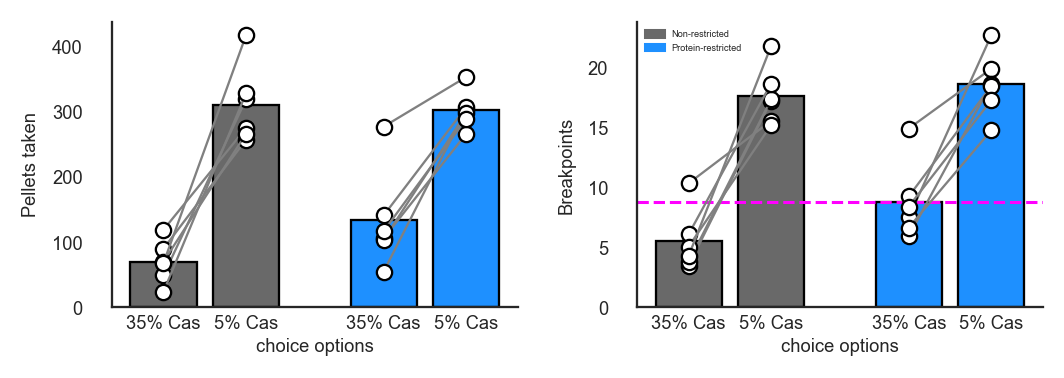

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import trompy as tp  #



# Remove gridlines by using the "white" style.
sns.set_style("white")

# Recode the numeric 'order' into a string 'diet' used for pivoting:
# Order 1 becomes "PR" (Protein-restricted) and Order 2 becomes "NR" (Non-restricted)
eco_df["diet"] = eco_df["order"].map({1: "PR", 2: "NR"})

# Create pivot tables with index [mouse, diet] and columns given by pellet_type.
n_pellets = pd.pivot_table(eco_df, values="n_pellets", index=["mouse", "diet"], columns="pellet_type")
breakpoint = pd.pivot_table(eco_df, values="avg_breakpoint", index=["mouse", "diet"], columns="pellet_type")

# Extract groups by diet, mimicking your original code:
NR_break = breakpoint.xs("NR", level="diet")  # Non-restricted
PR_break = breakpoint.xs("PR", level="diet")  # Protein-restricted

NR_pell = n_pellets.xs("NR", level="diet")
PR_pell = n_pellets.xs("PR", level="diet")

# -------------------------------------------------------------------
# SET UP FIGURE AND AXES (following your original style)
# -------------------------------------------------------------------
fig, axes = plt.subplots(ncols=2, 
                         figsize=(5, 1.88),  # ~2.5" wide per subplot
                         dpi=220)

# Define the colour scheme and legend patches.
# Non-restricted: dimgray; Protein-restricted: dodgerblue.
fed_cols = ["dimgray", "dimgray", "dodgerblue", "dodgerblue"]
NR_patch = mpatches.Patch(color="dimgray", label='Non-restricted')
PR_patch = mpatches.Patch(color="dodgerblue", label='Protein-restricted')

# -------------------------------------------------------------------
# FIRST SUBPLOT: Average Breakpoints
# -------------------------------------------------------------------
ax_break = axes[1]
tp.barscatter([[NR_break.RICH, NR_break.PR],
               [PR_break.RICH, PR_break.PR]],
              paired=True,
              barfacecolor=fed_cols,
              barfacecolor_option="individual",
              barlabels=["35% Cas", "5% Cas", "35% Cas", "5% Cas"],
              ax=ax_break, fontsize=6, scattersize=50)

ax_break.set_ylabel("Breakpoints", fontsize=6)
ax_break.set_xlabel("choice options", fontsize=6, labelpad=10)
ax_break.tick_params(labelsize=6)
ax_break.legend(handles=[NR_patch, PR_patch],
                loc="upper left",
                frameon=False,
                fontsize=3)

# Add a horizontal dashed line across the top of the 35% Cas bars.
NR_35 = NR_break.RICH.mean()  # Mean for Non-restricted 35% Cas
PR_35 = PR_break.RICH.mean()  # Mean for Protein-restricted 35% Cas
red_line_value = max(NR_35, PR_35)
ax_break.axhline(y=red_line_value, color='magenta', linestyle='--', linewidth=1)

# -------------------------------------------------------------------
# SECOND SUBPLOT: Total Pellets Taken
# -------------------------------------------------------------------
ax_pell = axes[0]
tp.barscatter([[NR_pell.RICH, NR_pell.PR],
               [PR_pell.RICH, PR_pell.PR]],
              paired=True,
              barfacecolor=fed_cols,
              barfacecolor_option="individual",
              barlabels=["35% Cas", "5% Cas", "35% Cas", "5% Cas"],
              ax=ax_pell, fontsize=6, scattersize=50)

ax_pell.set_ylabel("Pellets taken", fontsize=6)
ax_pell.set_xlabel("choice options", fontsize=6, labelpad=10)
ax_pell.tick_params(labelsize=6)

# -------------------------------------------------------------------
# FINAL STYLING AND DISPLAY/SAVE
# -------------------------------------------------------------------
sns.despine(fig=fig)  # Remove top/right spines.
plt.tight_layout()
plt.show()

#
# fig.savefig("combined_barscatter_eco.png", bbox_inches='tight', dpi=220)


ECO Metrics (one row per mouse & pellet choice):
      mouse pellet_type sex  order  n_pellets  avg_breakpoint
0   FEDXA01          PR   M    2.0         20        4.000000
1   FEDXA01        RICH   M    2.0         11        6.000000
2   FEDXA02          PR   M    2.0         30       12.000000
3   FEDXA02        RICH   M    2.0         14        5.000000
4   FEDXA03          PR   M    2.0         25        4.333333
5   FEDXA03        RICH   M    2.0          9        9.000000
6   FEDXA04          PR   M    2.0         29        8.000000
7   FEDXA04        RICH   M    2.0         13        3.666667
8   FEDXA05          PR   M    2.0         28        3.800000
9   FEDXA05        RICH   M    2.0          9        2.000000
10  FEDXA06          PR   M    2.0         48       15.500000
11  FEDXA06        RICH   M    2.0         14        5.000000
12  FEDXA07          PR   M    1.0         31       11.000000
13  FEDXA07        RICH   M    1.0         21        7.000000
14  FEDXA08          

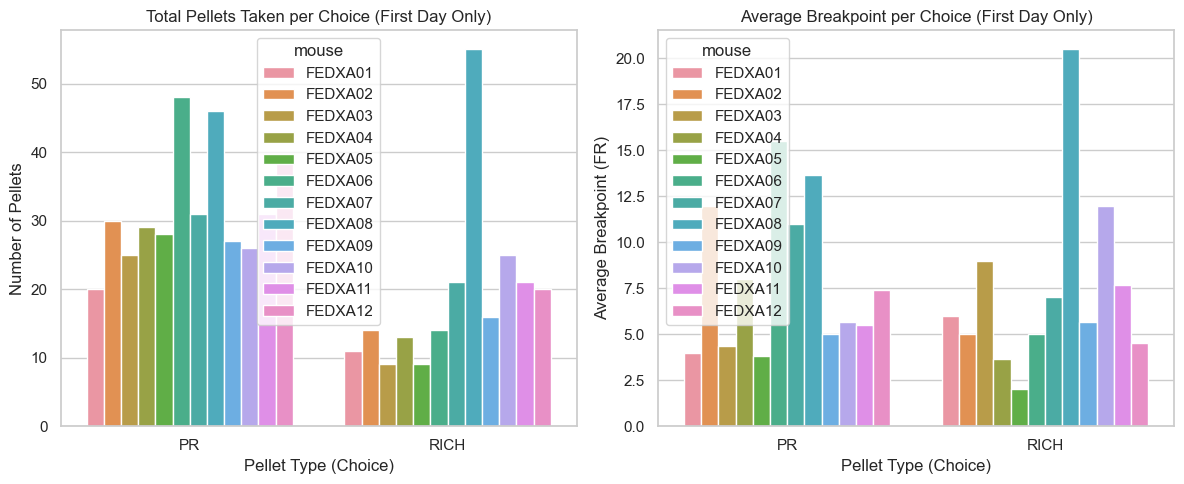

In [93]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import trompy as tp  # assumes this module provides your metafile reader

# ============================
# SETTINGS & FILE PATHS
# ============================
DATA_FOLDER = "../data"  # Adjust if needed
METAFILE = "../FEDProtein_METAFILE.xls"

# ============================
# READ THE METAFILE
# ============================
# The metafile is assumed to have rows with:
#   file, mouse, diet, mode, sex, order
rows, header = tp.metafilereader(METAFILE, sheetname="METAFILE")

# ============================
# ECO PIPELINE FUNCTIONS
# ============================
def tweak_eco(df, event="Left"):
    """
    Process an ECO file:
      - Rename the timestamp column,
      - Convert it to datetime and set as index,
      - Filter for the specified event (default "Left"),
      - Return the 'FR' column.
    """
    return (df
            .rename(columns={"MM:DD:YYYY hh:mm:ss": "t"})
            .assign(t=lambda d: pd.to_datetime(d.t))
            .set_index("t")
            .query("Event == @event")
            .loc[:, "FR"]
           )

def get_FR_reset_index(fr_series):
    """
    Returns the row indices (in a reset-index DataFrame) where FR equals 1.
    We assume that each reset indicates the beginning of a new bout.
    """
    return (fr_series
            .reset_index()
            .query("FR == 1")
            .reset_index()
            ["index"]
           )

def get_breakpoints(fr_series):
    """
    For each time the FR resets (i.e. FR == 1) after the first occurrence,
    take the FR value immediately before the reset.
    These values are considered the breakpoints.
    """
    reset_indices = get_FR_reset_index(fr_series)
    if len(reset_indices) <= 1:
        return np.array([])  # Not enough data to compute breakpoints
    indices = reset_indices[1:] - 1
    return fr_series.iloc[indices].values

def make_eco_df(file_path, mouse, diet, sex, order):
    """
    Reads one ECO file (covering 3 days of data) for one mouse/choice.
    Computes:
      - n_pellets: the total number of pellets taken **only on the first day**
      - avg_breakpoint: the average breakpoint, computed **only on the first day**
    Returns a one-row DataFrame with these metrics.
    """
    # Read the raw CSV file
    df_raw = pd.read_csv(file_path)

    # Convert timestamp column to datetime
    df_raw = df_raw.rename(columns={"MM:DD:YYYY hh:mm:ss": "t"})
    df_raw["t"] = pd.to_datetime(df_raw["t"])

    # Filter for the first day's data
    first_day = df_raw["t"].dt.date.min()  # Get the first date
    df_raw = df_raw[df_raw["t"].dt.date == first_day]  # Keep only first day's data

    # --- Pellet Count ---
    if "Pellet_Count" in df_raw.columns:
        n_pellets = df_raw["Pellet_Count"].max()
    else:
        n_pellets = len(df_raw)  # Fallback if Pellet_Count is missing

    # --- Average Breakpoint ---
    fr_series = tweak_eco(df_raw, event="Left")
    bp_values = get_breakpoints(fr_series)
    avg_bp = bp_values.mean() if len(bp_values) > 0 else np.nan

    return pd.DataFrame({
        "mouse": [mouse],
        "pellet_type": [diet],  
        "sex": [sex],
        "order": [order],
        "n_pellets": [n_pellets],  # Now includes only first day
        "avg_breakpoint": [avg_bp]  # Now includes only first day
    })

# ============================
# PROCESS ALL ECO FILES (FOR PR AND RICH CHOICES)
# ============================
eco_df = pd.DataFrame()

for row in rows:
    # Each row is assumed to have: file, mouse, diet, mode, sex, order
    file_name, mouse, diet, mode, sex, order = row
    # Process only ECO-mode files and pellet types of interest (PR and RICH)
    if (mode == "ECO") and (diet in ["PR", "RICH"]):
        file_path = os.path.join(DATA_FOLDER, file_name)
        df_temp = make_eco_df(file_path, mouse, diet, sex, order)
        eco_df = pd.concat([eco_df, df_temp], ignore_index=True)

# ============================
# OUTPUT & OPTIONAL PLOTTING
# ============================
print("ECO Metrics (one row per mouse & pellet choice):")
print(eco_df)

# # Save the results to a CSV file
# eco_df.to_csv("eco_metrics.csv", index=False)

# Optionally, create plots of the results:
sns.set(style="whitegrid")
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

# Bar plot for total pellets taken (only first-day data)
sns.barplot(data=eco_df, x="pellet_type", y="n_pellets", hue="mouse", ax=axes[0])
axes[0].set_title("Total Pellets Taken per Choice (First Day Only)")
axes[0].set_ylabel("Number of Pellets")
axes[0].set_xlabel("Pellet Type (Choice)")

# Bar plot for average breakpoint (only first-day data)
sns.barplot(data=eco_df, x="pellet_type", y="avg_breakpoint", hue="mouse", ax=axes[1])
axes[1].set_title("Average Breakpoint per Choice (First Day Only)")
axes[1].set_ylabel("Average Breakpoint (FR)")
axes[1].set_xlabel("Pellet Type (Choice)")

plt.tight_layout()
plt.show()


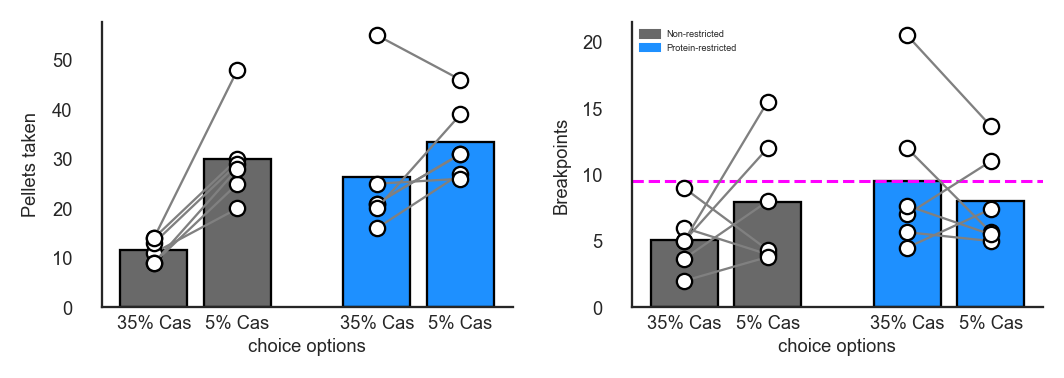

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import trompy as tp  # 



# Remove gridlines by using the "white" style.
sns.set_style("white")

# Recode the numeric 'order' into a string 'diet' used for pivoting:
# Order 1 becomes "PR" (Protein-restricted) and Order 2 becomes "NR" (Non-restricted)
eco_df["diet"] = eco_df["order"].map({1: "PR", 2: "NR"})

# Create pivot tables with index [mouse, diet] and columns given by pellet_type.
n_pellets = pd.pivot_table(eco_df, values="n_pellets", index=["mouse", "diet"], columns="pellet_type")
breakpoint = pd.pivot_table(eco_df, values="avg_breakpoint", index=["mouse", "diet"], columns="pellet_type")

# Extract groups by diet, mimicking your original code:
NR_break = breakpoint.xs("NR", level="diet")  # Non-restricted
PR_break = breakpoint.xs("PR", level="diet")  # Protein-restricted

NR_pell = n_pellets.xs("NR", level="diet")
PR_pell = n_pellets.xs("PR", level="diet")

# -------------------------------------------------------------------
# SET UP FIGURE AND AXES (following your original style)
# -------------------------------------------------------------------
fig, axes = plt.subplots(ncols=2, 
                         figsize=(5, 1.88),  # ~2.5" wide per subplot
                         dpi=220)

# Define the colour scheme and legend patches.
# Non-restricted: dimgray; Protein-restricted: dodgerblue.
fed_cols = ["dimgray", "dimgray", "dodgerblue", "dodgerblue"]
NR_patch = mpatches.Patch(color="dimgray", label='Non-restricted')
PR_patch = mpatches.Patch(color="dodgerblue", label='Protein-restricted')

# -------------------------------------------------------------------
# FIRST SUBPLOT: Average Breakpoints
# -------------------------------------------------------------------
ax_break = axes[1]
tp.barscatter([[NR_break.RICH, NR_break.PR],
               [PR_break.RICH, PR_break.PR]],
              paired=True,
              barfacecolor=fed_cols,
              barfacecolor_option="individual",
              barlabels=["35% Cas", "5% Cas", "35% Cas", "5% Cas"],
              ax=ax_break, fontsize=6, scattersize=50)

ax_break.set_ylabel("Breakpoints", fontsize=6)
ax_break.set_xlabel("choice options", fontsize=6, labelpad=10)
ax_break.tick_params(labelsize=6)
ax_break.legend(handles=[NR_patch, PR_patch],
                loc="upper left",
                frameon=False,
                fontsize=3)

# Add a horizontal dashed line across the top of the 35% Cas bars.
NR_35 = NR_break.RICH.mean()  # Mean for Non-restricted 35% Cas
PR_35 = PR_break.RICH.mean()  # Mean for Protein-restricted 35% Cas
red_line_value = max(NR_35, PR_35)
ax_break.axhline(y=red_line_value, color='magenta', linestyle='--', linewidth=1)

# -------------------------------------------------------------------
# SECOND SUBPLOT: Total Pellets Taken
# -------------------------------------------------------------------
ax_pell = axes[0]
tp.barscatter([[NR_pell.RICH, NR_pell.PR],
               [PR_pell.RICH, PR_pell.PR]],
              paired=True,
              barfacecolor=fed_cols,
              barfacecolor_option="individual",
              barlabels=["35% Cas", "5% Cas", "35% Cas", "5% Cas"],
              ax=ax_pell, fontsize=6, scattersize=50)

ax_pell.set_ylabel("Pellets taken", fontsize=6)
ax_pell.set_xlabel("choice options", fontsize=6, labelpad=10)
ax_pell.tick_params(labelsize=6)

# -------------------------------------------------------------------
# FINAL STYLING AND DISPLAY/SAVE
# -------------------------------------------------------------------
sns.despine(fig=fig)  # Remove top/right spines.
plt.tight_layout()
plt.show()

# Optionally, save your figure:
# fig.savefig("combined_barscatter_eco.png", bbox_inches='tight', dpi=220)


ECO Metrics (one row per mouse & pellet choice):
      mouse pellet_type sex  order  n_pellets  avg_breakpoint  \
0   FEDXA01          PR   M    2.0        319       17.277778   
1   FEDXA01        RICH   M    2.0         49        3.500000   
2   FEDXA02          PR   M    2.0        275       15.588235   
3   FEDXA02        RICH   M    2.0        119       10.363636   
4   FEDXA03          PR   M    2.0        328       17.388889   
5   FEDXA03        RICH   M    2.0         24        3.769231   
6   FEDXA04          PR   M    2.0        257       18.703704   
7   FEDXA04        RICH   M    2.0         90        6.103448   
8   FEDXA05          PR   M    2.0        266       15.235294   
9   FEDXA05        RICH   M    2.0         70        5.071429   
10  FEDXA06          PR   M    2.0        417       21.833333   
11  FEDXA06        RICH   M    2.0         68        4.290323   
12  FEDXA07          PR   M    1.0        266       22.739130   
13  FEDXA07        RICH   M    1.0       

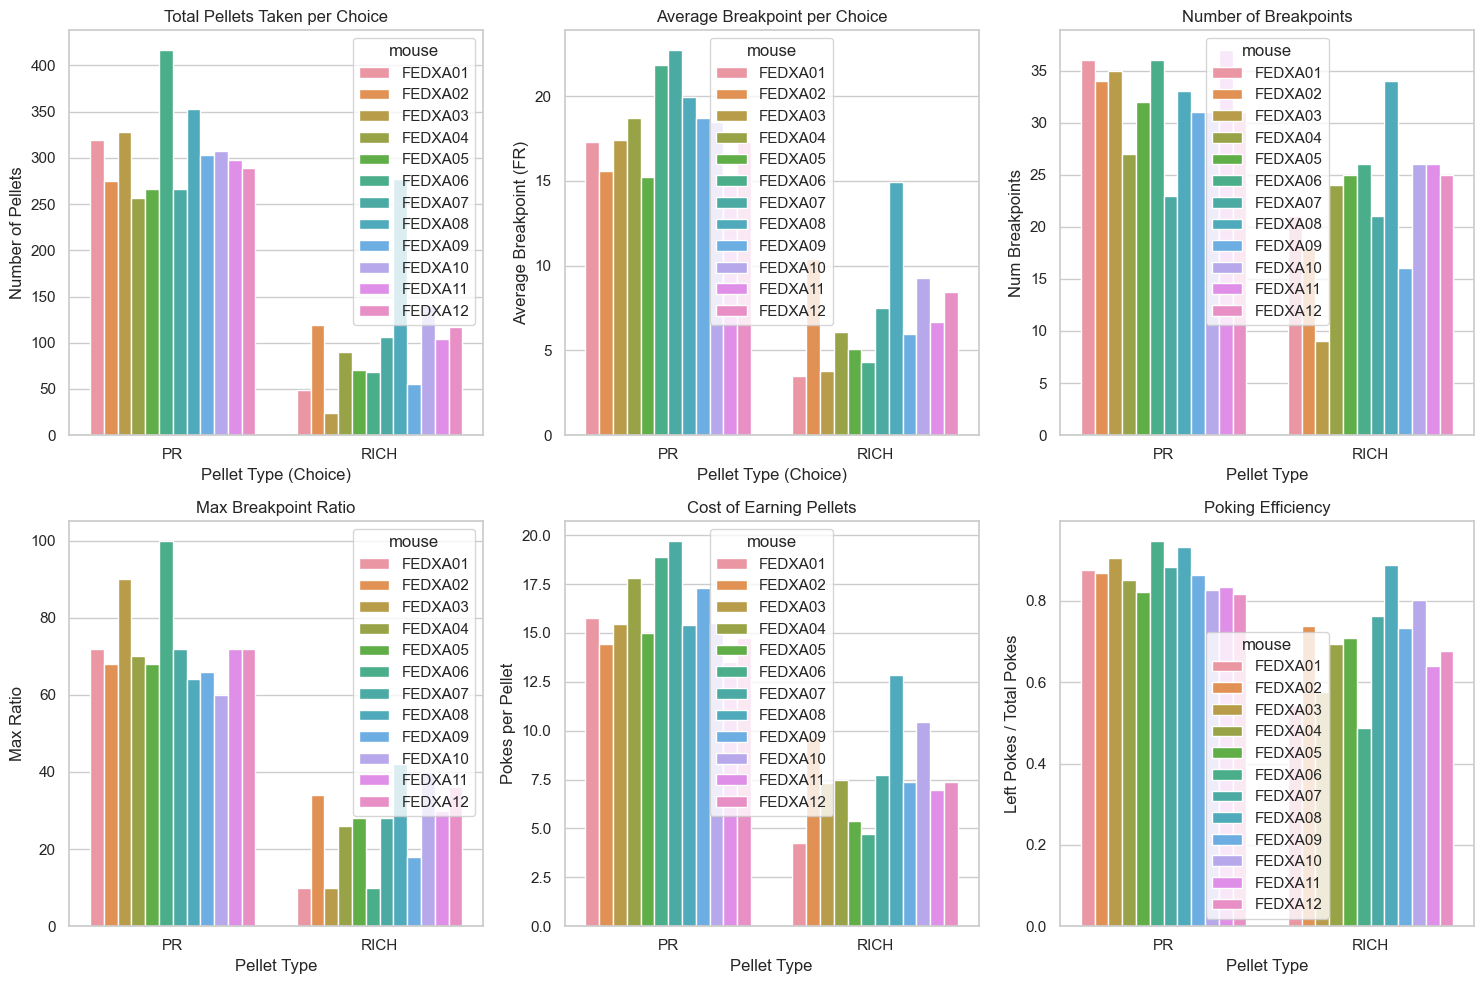

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import trompy as tp 

# ============================
# SETTINGS & FILE PATHS
# ============================
DATA_FOLDER = "../data"  # adjust if needed
METAFILE = "../FEDProtein_METAFILE.xls"

# ============================
# READ THE METAFILE
# ============================
# The metafile is assumed to have rows with:
#   file, mouse, diet, mode, sex, order
rows, header = tp.metafilereader(METAFILE, sheetname="METAFILE")

# ============================
# ECO PIPELINE FUNCTIONS
# ============================

def tweak_eco(df, event="Left"):
    """
    Process an ECO file:
      - Rename the timestamp column,
      - Convert it to datetime and set as index,
      - Filter for the specified event (default "Left"),
      - Return the 'FR' column.
    """
    return (df
            .rename(columns={"MM:DD:YYYY hh:mm:ss": "t"})
            .assign(t=lambda d: pd.to_datetime(d.t))
            .set_index("t")
            .query("Event == @event")
            .loc[:, "FR"]
           )

def get_FR_reset_index(fr_series):
    """
    Returns the row indices (in a reset-index DataFrame) where FR equals 1.
    We assume that each reset indicates the beginning of a new bout.
    """
    return (fr_series
            .reset_index()
            .query("FR == 1")
            .reset_index()
            ["index"]
           )

def get_breakpoints(fr_series):
    """
    For each time the FR resets (i.e. FR == 1) after the first occurrence,
    take the FR value immediately before the reset.
    These values are considered the breakpoints.
    """
    reset_indices = get_FR_reset_index(fr_series)
    if len(reset_indices) <= 1:
        return np.array([])  #
    indices = reset_indices[1:] - 1
    return fr_series.iloc[indices].values

def calculate_breakpoints(df):
    """
    Calculate:
      - Number of breakpoints
      - Max breakpoint ratio
    """
    FR = df["FR"]
    breakpoints = [abs(val) for idx, val in enumerate(np.diff(FR)) if val < 0]
    num_breakpoints = len(breakpoints)
    max_breakpoint_ratio = max(breakpoints) if breakpoints else 0
    return num_breakpoints, max_breakpoint_ratio

def get_max_pellets(df):
    """
    Returns the max number of pellets collected.
    """
    return df["Pellet_Count"].max()

def calculate_cost_and_efficiency(df):
    """
    Calculate:
      - Cost of earning pellets: (Total Pokes / Total Pellets)
      - Efficiency of poking strategy: (Left Pokes / Total Pokes)
    """
    total_pokes = df["Left_Poke_Count"].sum() + df["Right_Poke_Count"].sum()
    total_pellets = df["Pellet_Count"].sum()
    
    cost = df["Left_Poke_Count"].sum() / total_pellets if total_pellets > 0 else np.nan
    efficiency = df["Left_Poke_Count"].sum() / total_pokes if total_pokes > 0 else np.nan
    
    return cost, efficiency

def make_eco_df(file_path, mouse, diet, sex, order):
    """
    Reads one ECO file (covering 3 days of data) for one mouse/choice.
    Computes:
      - n_pellets: total number of pellets taken
      - avg_breakpoint: average breakpoint
      - num_breakpoints: number of times a breakpoint was reached
      - max_breakpoint_ratio: maximum breakpoint ratio
      - cost: cost of earning pellets (pokes per pellet)
      - efficiency: efficiency of poking strategy
    Returns a one-row DataFrame with these metrics.
    """
    # Read the raw CSV file
    df_raw = pd.read_csv(file_path)
    
    # --- Pellet Count ---
    if "Pellet_Count" in df_raw.columns:
        n_pellets = df_raw["Pellet_Count"].max()
    else:
        n_pellets = len(df_raw)  # Fallback if Pellet_Count is missing

    # --- Breakpoints ---
    fr_series = tweak_eco(df_raw, event="Left")
    bp_values = get_breakpoints(fr_series)
    avg_bp = bp_values.mean() if len(bp_values) > 0 else np.nan

    # --- Number of Breakpoints and Max Breakpoint Ratio ---
    num_breakpoints, max_breakpoint_ratio = calculate_breakpoints(df_raw)

    # --- Cost & Efficiency ---
    cost, efficiency = calculate_cost_and_efficiency(df_raw)

    return pd.DataFrame({
        "mouse": [mouse],
        "pellet_type": [diet],  
        "sex": [sex],
        "order": [order],
        "n_pellets": [n_pellets],  
        "avg_breakpoint": [avg_bp],
        "num_breakpoints": [num_breakpoints],
        "max_breakpoint_ratio": [max_breakpoint_ratio],
        "cost": [cost],
        "efficiency": [efficiency]
    })

# ============================
# PROCESS ALL ECO FILES (for PR and RICH choices)
# ============================
eco_df = pd.DataFrame()

for row in rows:
    file_name, mouse, diet, mode, sex, order = row
    if (mode == "ECO") and (diet in ["PR", "RICH"]):
        file_path = os.path.join(DATA_FOLDER, file_name)
        df_temp = make_eco_df(file_path, mouse, diet, sex, order)
        eco_df = pd.concat([eco_df, df_temp], ignore_index=True)

# ============================
# OUTPUT & OPTIONAL PLOTTING
# ============================
print("ECO Metrics (one row per mouse & pellet choice):")
print(eco_df)

# Save the results to a CSV file
eco_df.to_csv("eco_metrics.csv", index=False)

# ============================
# PLOTTING
# ============================
sns.set(style="whitegrid")
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(15, 10))

# Bar plot for total pellets taken
sns.barplot(data=eco_df, x="pellet_type", y="n_pellets", hue="mouse", ax=axes[0, 0])
axes[0, 0].set_title("Total Pellets Taken per Choice")
axes[0, 0].set_ylabel("Number of Pellets")
axes[0, 0].set_xlabel("Pellet Type (Choice)")

# Bar plot for average breakpoint
sns.barplot(data=eco_df, x="pellet_type", y="avg_breakpoint", hue="mouse", ax=axes[0, 1])
axes[0, 1].set_title("Average Breakpoint per Choice")
axes[0, 1].set_ylabel("Average Breakpoint (FR)")
axes[0, 1].set_xlabel("Pellet Type (Choice)")

# Bar plot for number of breakpoints
sns.barplot(data=eco_df, x="pellet_type", y="num_breakpoints", hue="mouse", ax=axes[0, 2])
axes[0, 2].set_title("Number of Breakpoints")
axes[0, 2].set_ylabel("Num Breakpoints")
axes[0, 2].set_xlabel("Pellet Type")

# Bar plot for max breakpoint ratio
sns.barplot(data=eco_df, x="pellet_type", y="max_breakpoint_ratio", hue="mouse", ax=axes[1, 0])
axes[1, 0].set_title("Max Breakpoint Ratio")
axes[1, 0].set_ylabel("Max Ratio")
axes[1, 0].set_xlabel("Pellet Type")

# Cost
sns.barplot(data=eco_df, x="pellet_type", y="cost", hue="mouse", ax=axes[1, 1])
axes[1, 1].set_title("Cost of Earning Pellets")
axes[1, 1].set_ylabel("Pokes per Pellet")
axes[1, 1].set_xlabel("Pellet Type")

# Efficiency
sns.barplot(data=eco_df, x="pellet_type", y="efficiency", hue="mouse", ax=axes[1, 2])
axes[1, 2].set_title("Poking Efficiency")
axes[1, 2].set_ylabel("Left Pokes / Total Pokes")
axes[1, 2].set_xlabel("Pellet Type")

plt.tight_layout()
plt.show()


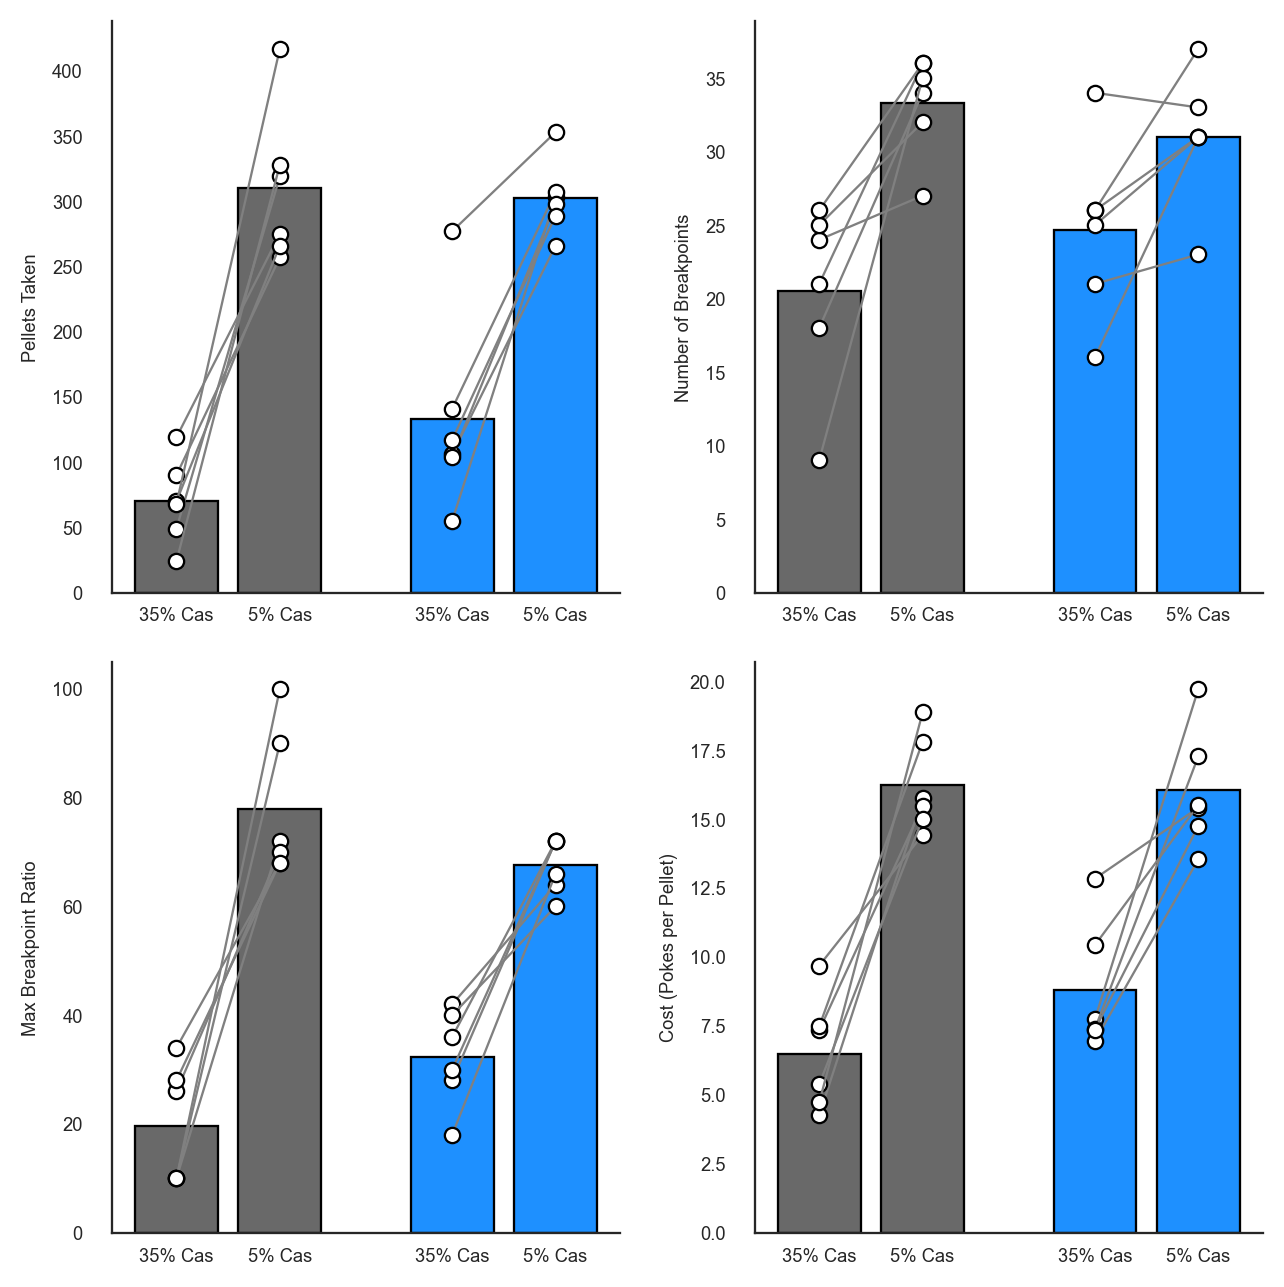

ECO Metrics (one row per mouse & pellet choice):
      mouse pellet_type sex  order  n_pellets  num_breakpoints  \
0   FEDXA01          PR   M    2.0        319               36   
1   FEDXA01        RICH   M    2.0         49               21   
2   FEDXA02          PR   M    2.0        275               34   
3   FEDXA02        RICH   M    2.0        119               18   
4   FEDXA03          PR   M    2.0        328               35   
5   FEDXA03        RICH   M    2.0         24                9   
6   FEDXA04          PR   M    2.0        257               27   
7   FEDXA04        RICH   M    2.0         90               24   
8   FEDXA05          PR   M    2.0        266               32   
9   FEDXA05        RICH   M    2.0         70               25   
10  FEDXA06          PR   M    2.0        417               36   
11  FEDXA06        RICH   M    2.0         68               26   
12  FEDXA07          PR   M    1.0        266               23   
13  FEDXA07        RICH   M

In [101]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import trompy as tp  

# ============================
# SETTINGS & FILE PATHS
# ============================
DATA_FOLDER = "../data"
METAFILE = "../FEDProtein_METAFILE.xls"

# ============================
# READ THE METAFILE
# ============================
rows, header = tp.metafilereader(METAFILE, sheetname="METAFILE")

# ============================
# ECO PIPELINE FUNCTIONS
# ============================

def calculate_breakpoints(df):
    """Calculate number of breakpoints and max breakpoint ratio."""
    FR = df["FR"]
    breakpoints = [abs(val) for idx, val in enumerate(np.diff(FR)) if val < 0]
    num_breakpoints = len(breakpoints)
    max_breakpoint_ratio = max(breakpoints) if breakpoints else 0
    return num_breakpoints, max_breakpoint_ratio

def get_max_pellets(df):
    """Returns the max number of pellets collected."""
    return df["Pellet_Count"].max()

def calculate_cost(df):
    """Calculate cost of earning pellets (Total Pokes / Total Pellets)."""
    total_pokes = df["Left_Poke_Count"].sum() + df["Right_Poke_Count"].sum()
    total_pellets = df["Pellet_Count"].sum()
    cost = df["Left_Poke_Count"].sum() / total_pellets if total_pellets > 0 else np.nan
    return cost

def make_eco_df(file_path, mouse, diet, sex, order):
    """Computes all metrics and returns a one-row DataFrame."""
    df_raw = pd.read_csv(file_path)

    # Pellet Count
    n_pellets = get_max_pellets(df_raw)

    # Breakpoints
    num_breakpoints, max_breakpoint_ratio = calculate_breakpoints(df_raw)

    # Cost
    cost = calculate_cost(df_raw)

    return pd.DataFrame({
        "mouse": [mouse],
        "pellet_type": [diet],  
        "sex": [sex],
        "order": [order],
        "n_pellets": [n_pellets],
        "num_breakpoints": [num_breakpoints],
        "max_breakpoint_ratio": [max_breakpoint_ratio],
        "cost": [cost]
    })

# ============================
# PROCESS ALL ECO FILES
# ============================
eco_df = pd.DataFrame()

for row in rows:
    file_name, mouse, diet, mode, sex, order = row
    if (mode == "ECO") and (diet in ["PR", "RICH"]):
        file_path = os.path.join(DATA_FOLDER, file_name)
        df_temp = make_eco_df(file_path, mouse, diet, sex, order)
        eco_df = pd.concat([eco_df, df_temp], ignore_index=True)

# ============================
# PLOTTING STYLE
# ============================
sns.set_style("white")

# Recode numeric 'order' into a string 'diet':
eco_df["diet"] = eco_df["order"].map({1: "PR", 2: "NR"})

# Create pivot tables with index [mouse, diet] and columns given by pellet_type.
metrics = ["n_pellets", "num_breakpoints", "max_breakpoint_ratio", "cost"]
pivot_data = {metric: pd.pivot_table(eco_df, values=metric, index=["mouse", "diet"], columns="pellet_type") for metric in metrics}

# Extract Non-restricted (NR) and Protein-restricted (PR) groups:
NR_data = {metric: pivot_data[metric].xs("NR", level="diet") for metric in metrics}
PR_data = {metric: pivot_data[metric].xs("PR", level="diet") for metric in metrics}

# Define the color scheme:
fed_cols = ["dimgray", "dimgray", "dodgerblue", "dodgerblue"]
NR_patch = mpatches.Patch(color="dimgray", label='Non-restricted')
PR_patch = mpatches.Patch(color="dodgerblue", label='Protein-restricted')

# ============================
# PLOT BARS & SCATTERS (4 PLOTS)
# ============================
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(6, 6), dpi=220)

# Flatten axes array for easier indexing
axes = axes.flatten()

# Define labels for the 4 plots:
metric_labels = {
    "n_pellets": "Pellets Taken",
    "num_breakpoints": "Number of Breakpoints",
    "max_breakpoint_ratio": "Max Breakpoint Ratio",
    "cost": "Cost (Pokes per Pellet)"
}

# Plot each metric using barscatter
for ax, (metric, label) in zip(axes, metric_labels.items()):
    tp.barscatter([[NR_data[metric]["RICH"], NR_data[metric]["PR"]],
                   [PR_data[metric]["RICH"], PR_data[metric]["PR"]]],
                  paired=True,
                  barfacecolor=fed_cols,
                  barfacecolor_option="individual",
                  barlabels=["35% Cas", "5% Cas", "35% Cas", "5% Cas"],
                  ax=ax, fontsize=6, scattersize=50)

    ax.set_ylabel(label, fontsize=6)
    ax.tick_params(labelsize=6)  #

# Adjust layout
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

# Optionally, save the figure:
# fig.savefig("eco_metrics_barscatter.png", bbox_inches='tight', dpi=220)

# ============================
# SAVE OUTPUT
# ============================
# eco_df.to_csv("eco_metrics.csv", index=False)
print("ECO Metrics (one row per mouse & pellet choice):")
print(eco_df)


11 items in output dictionary
11 items in output dictionary
11 items in output dictionary


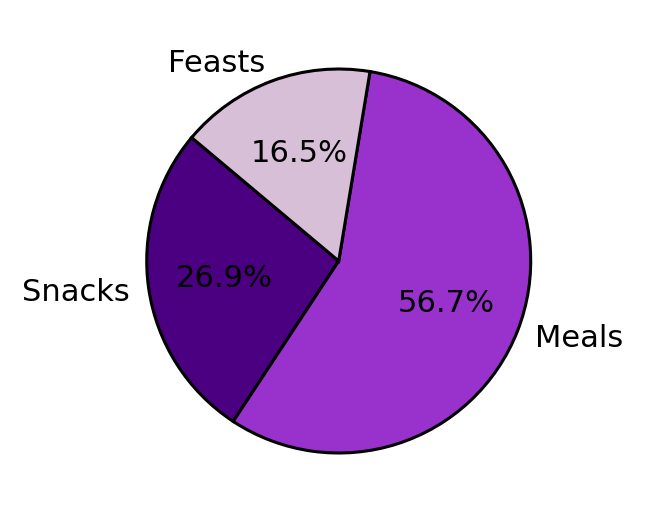

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Extract data for Order 1 (NR diet) mice
nr_meals = get_data_fields(mice, ["nr_number_of_meals"], {"order": 1})
nr_snacks = get_data_fields(mice, ["nr_number_of_snacks"], {"order": 1})
nr_feasts = get_data_fields(mice, ["nr_number_of_mega_meals"], {"order": 1})

# Compute the average for each feeding category
avg_meals = np.mean(nr_meals)
avg_snacks = np.mean(nr_snacks)
avg_feasts = np.mean(nr_feasts)

# Data for pie chart
feeding_categories = ["Snacks", "Meals", "Feasts"]
feeding_values = [avg_snacks, avg_meals, avg_feasts]
colors = ["indigo", "darkorchid", "thistle"]

# Create pie chart
fig, ax = plt.subplots(figsize=(3, 3), dpi=220)
ax.pie(
    feeding_values, labels=feeding_categories, autopct='%1.1f%%', colors=colors,
    startangle=140, wedgeprops={'edgecolor': 'black'}
)

# Add title
plt.title("", fontsize=8)

# Legend
legend_elements = [
    Patch(facecolor='indigo', edgecolor='black', label='Snack'), 
    Patch(facecolor='darkorchid', edgecolor='black', label='Meal'), 
    Patch(facecolor='thistle', edgecolor='black', label='Feast')
]
# ax.legend(handles=legend_elements, loc="upper right", fontsize=6, frameon=False)

# Display plot
plt.tight_layout()
plt.show()

# Save figure
fig.savefig("../plots/NEW_MEAL_PLOTS/Order1_NR_Food_Pie.png", bbox_inches='tight', dpi=220)


11 items in output dictionary
11 items in output dictionary
11 items in output dictionary


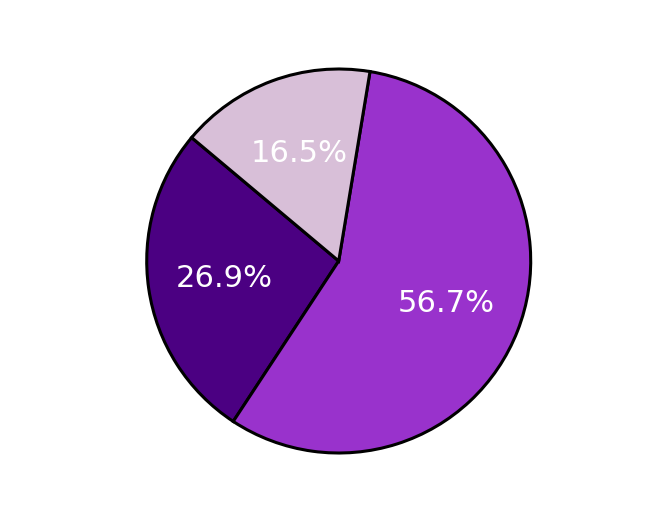

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Extract data for Order 1 (NR diet) mice
nr_meals = get_data_fields(mice, ["nr_number_of_meals"], {"order": 1})
nr_snacks = get_data_fields(mice, ["nr_number_of_snacks"], {"order": 1})
nr_feasts = get_data_fields(mice, ["nr_number_of_mega_meals"], {"order": 1})

# Compute the average for each feeding category
avg_meals = np.mean(nr_meals)
avg_snacks = np.mean(nr_snacks)
avg_feasts = np.mean(nr_feasts)

# Data for pie chart
feeding_categories = ["Snacks", "Meals", "Feasts"]
feeding_values = [avg_snacks, avg_meals, avg_feasts]
colors = ["indigo", "darkorchid", "thistle"]

# Create pie chart
fig, ax = plt.subplots(figsize=(3, 3), dpi=220)
ax.pie(
    feeding_values, labels=feeding_categories, autopct='%1.1f%%', colors=colors,
    startangle=140, wedgeprops={'edgecolor': 'black'}, textprops={'color': 'white'}
)

# Add title
plt.title("", fontsize=8)

# Legend
legend_elements = [
    Patch(facecolor='indigo', edgecolor='black', label='Snack'), 
    Patch(facecolor='darkorchid', edgecolor='black', label='Meal'), 
    Patch(facecolor='thistle', edgecolor='black', label='Feast')
]
# ax.legend(handles=legend_elements, loc="upper right", fontsize=6, frameon=False)

# Display plot
plt.tight_layout()
plt.show()

# Save figure
fig.savefig("../plots/NEW_MEAL_PLOTS/Order1_NR_Food_Pie.png", bbox_inches='tight', dpi=220)


11 items in output dictionary
11 items in output dictionary
11 items in output dictionary


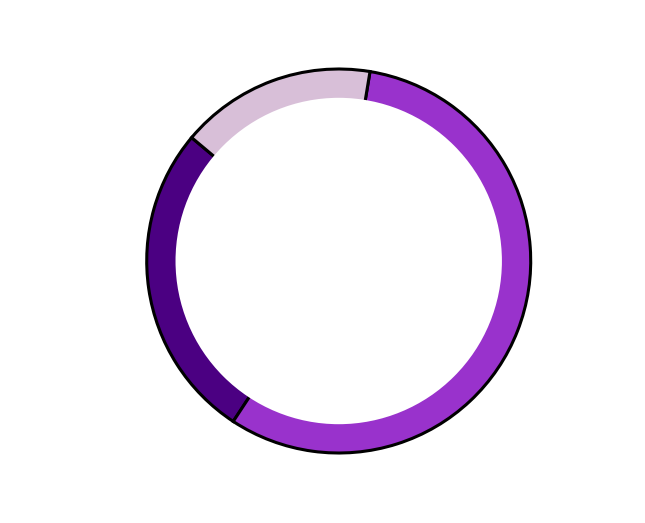

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Extract data for Order 1 (NR diet) mice
nr_meals = get_data_fields(mice, ["nr_number_of_meals"], {"order": 1})
nr_snacks = get_data_fields(mice, ["nr_number_of_snacks"], {"order": 1})
nr_feasts = get_data_fields(mice, ["nr_number_of_mega_meals"], {"order": 1})

# Compute the average for each feeding category
avg_meals = np.mean(nr_meals)
avg_snacks = np.mean(nr_snacks)
avg_feasts = np.mean(nr_feasts)

# Data for doughnut chart
feeding_categories = ["Snacks", "Meals", "Feasts"]
feeding_values = [avg_snacks, avg_meals, avg_feasts]
colors = ["indigo", "darkorchid", "thistle"]

# Create doughnut chart (narrow circle)
fig, ax = plt.subplots(figsize=(3, 3), dpi=220)
ax.pie(
    feeding_values, labels=feeding_categories, autopct='%1.1f%%', colors=colors,
    startangle=140, wedgeprops={'edgecolor': 'black', 'width': 0.2}, textprops={'color': 'white'}
)

# Add white circle in the middle to create the doughnut effect
centre_circle = plt.Circle((0, 0), 0.85, fc='white')
fig.gca().add_artist(centre_circle)

# Title
plt.title("", fontsize=8)

# Legend
legend_elements = [
    Patch(facecolor='indigo', edgecolor='black', label='Snack'), 
    Patch(facecolor='darkorchid', edgecolor='black', label='Meal'), 
    Patch(facecolor='thistle', edgecolor='black', label='Feast')
]
# ax.legend(handles=legend_elements, loc="upper right", fontsize=6, frameon=False)

# Show and save
plt.tight_layout()
plt.show()
#fig.savefig("../plots/NEW_MEAL_PLOTS/Order1_NR_Food_Doughnut.png", bbox_inches='tight', dpi=220)
